# 08 日度实现波动率的 ARFIMA 长记忆估计

本 Notebook 直接从正式 `silver` 分钟事实重建固定三个月交割合约、15/30/60 分钟收益和日度实现方差，再对

\[
y_t^{(m)}=\log\widehat\sigma_t^{(m)}
=\frac12\log RV_t^{(m)},\qquad
RV_t^{(m)}=\sum_{n=1}^{N_m}r_{t,n}^{(m)2}
\]

估计 ARFIMA。它不读取第 01—07 项的输出，也不写缓存、`silver` 或 `gold`。

## 1. 在做什么，以及经济意义

GARCH 家族直接描述收益的条件方差；ARFIMA 先把一天的盘中路径压缩为实现方差，再描述**日度波动水平本身**的长记忆。这里关心：

- `d>0` 是否显著：波动冲击不是指数衰减，而是以更慢的双曲速度消退；
- 15/30/60 分钟 RV 的 `d` 是否稳定：长记忆结论是否依赖采样频率；
- 分数差分之后的 AR(1) 是否仍显著：长期记忆之外是否还有短期均值回归；
- RB 的 MA(1) 是否值得加入：以 BIC 比较 `(1,d,0)` 基线和 `(1,d,1)` 敏感性。

本项仍是入样本结构估计，不判断预测胜负。ARFIMA 与 GARCH 家族的共同样本外比较在第 09—12 项完成。

## 2. 论文公式、Table 6 与当前复现等级

论文公式 (3) 为

\[
\phi(L)(1-L)^d(y_t-\mu)=\theta(L)\varepsilon_t,
\]

公式 (4) 又给出 `RV = sigma^2 = sum(r^2)`，所以论文文字中的 `log(sigma)` 对应可执行目标 `0.5*log(RV)`，不是 `log(RV)`。Table 6 对 AL、CU、FU 使用 `(1,d,0)`，报告 AR(1)、`d` 及 t 值；论文原样本的 `d` 为 0.33—0.47。SR 使用 `(1,d,1)`，但本项目因无分钟事实排除 SR，并依冻结口径对 RB 使用 `(1,d,0)` 基线、另报 `(1,d,1)` BIC 敏感性。

论文未披露 ARFIMA 的误差分布、精确或条件似然、初始化、分数差分截断、优化器、参数边界、标准误和零 RV 处理。本项目公开采用：

- 采用与 Table 6 正负号及正文“negative AR”解释一致的常规递推符号 `(1-phi*L)(1-L)^d(y-mu)=(1+theta*L)epsilon`；论文公式印成 `1+phi*L`，该不一致作为排版/软件约定歧义保留披露；
- 有限历史全长分数差分、零预样本条件、Gaussian conditional sum of squares；`mu` 与创新方差在每组结构参数下解析剖面；
- `|phi|,|theta|<=0.999`、`-0.499<=d<=0.499`，保持协方差平稳 ARFIMA；固定多起点 L-BFGS-B；
- 在 `[mu,phi,d,(theta),log(sigma^2)]` 未剖面联合参数上重算观察 Hessian，生成普通 Wald t 值。Hessian 非正定或病态时报告 `NA`，不使用伪逆；星号由当前 p 值生成；
- 对“所有槽位收益都在 `1e-12` 容差内”的日 RV，用**该序列、该频率初始样本实质最小正 RV 的一半**作检测下限。该规则保留完整日网格且不使用 OOS 信息；另用初始实质正 RV 的 0.5% 分位数一半报告检测下限敏感性。

论文交易日为 240 分钟；项目真实日盘为 225 分钟，因此 30/60 分钟末槽分别只有 15/45 分钟。这是方法复现，不是 GTA 数值复刻。

In [1]:
from __future__ import annotations

from datetime import date
import gc
import pathlib
import sys
import time

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()

for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        sys.path.insert(0, str(candidate_root / "02_Futures_Lakehouse"))
        project_root = candidate_root
        break
else:
    raise RuntimeError("未找到项目根目录")

expected_python = pathlib.Path("E:/anaconda3/envs/latitude_env_v2/python.exe").resolve()
current_python = pathlib.Path(sys.executable).resolve()
assert current_python == expected_python, (
    f"必须使用 latitude_env_v2 环境解释器 {expected_python}，实际为 {current_python}"
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
import scipy
from scipy.optimize import minimize
from scipy.signal import fftconvolve, lfilter
from scipy.stats import norm
import statsmodels
from statsmodels.tools.numdiff import approx_hess
from IPython.display import Markdown, display

from config.data_contracts import (
    FUTURES_BAR_CALENDAR_SCHEMA,
    FUTURES_CONTRACT_CALENDAR_SCHEMA,
    FUTURES_MINUTE_SCHEMA,
    FUTURES_VARIETY_CALENDAR_SCHEMA,
    arrow_to_pandas,
    validate_arrow_table,
)
from a00_03_notebook_schema_browser import display_schema_metadata
from config.settings import settings

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 400)
pd.set_option("display.width", 220)

print(f"Python: {sys.executable}")
print(f"NumPy={np.__version__}; SciPy={scipy.__version__}; statsmodels={statsmodels.__version__}")
print(f"项目根目录: {project_root}")
print(f"正式湖仓根目录: {settings.futures_lake_root}")

Python: E:\anaconda3\envs\latitude\python.exe
NumPy=2.4.3; SciPy=1.17.1; statsmodels=0.14.6
项目根目录: E:\Latitude_Analytics_v2
正式湖仓根目录: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake


## 3. 开篇 Schema metadata 浏览器

In [2]:
display_schema_metadata(
    [
        FUTURES_VARIETY_CALENDAR_SCHEMA,
        FUTURES_CONTRACT_CALENDAR_SCHEMA,
        FUTURES_BAR_CALENDAR_SCHEMA,
        FUTURES_MINUTE_SCHEMA,
    ]
)

英文表名,中文表名,字段数,主键,Hive 分区,Schema 版本
dim_futures_variety_calendar,期货品种交易日历维度表,8,"exchange_code,underlying_code,trading_date","exchange_code,year,month",1.2.0
dim_futures_contract_calendar,期货合约 Session 日历维度表,21,"contract_code,trading_date,session_number","exchange_code,year,month",1.2.0
dim_futures_bar_calendar,期货行情拉取与质检日历维度表,48,"bar_frequency,contract_code,trading_date,session_number","bar_frequency,exchange_code,year,month",1.4.0
fact_futures_minute,国内期货合约一分钟行情事实表,17,"contract_code,bar_at","exchange_code,underlying_code,year,month",1.5.0


## 4. 参数、固定样本与代码步骤

代码按以下顺序线性展开：

1. 构造固定三个月交割合约链并执行真实日盘 Session 门禁；
2. 一次分钟扫描生成 15/30/60 分钟原始收益；
3. 逐日求 `sum(r^2)`，识别有效零 RV，并以初始样本检测下限得到有限 `0.5*log(RV)`；
4. 保留最后 300/200 日为 OOS，仅在初始样本估计 15 个 `(1,d,0)` 基线；
5. 估计 15 个 0.5% 分位数检测下限敏感性和 3 个 RB `(1,d,1)` BIC 敏感性；
6. 生成 Table 6 风格结果、`d` 图、独立公式复核和验证门禁。

In [3]:
exchange_code = "XSGE"
sample_start = date(2010, 1, 4)
sample_end = date(2026, 8, 28)
zero_return_tolerance = 1e-12
rv_floor_multiplier = 0.5

ar_ma_absolute_bound = 0.999
fractional_d_bound = 0.499
optimizer_max_iterations = 1000
optimizer_ftol = 1e-10
hessian_step = 1e-4
hessian_condition_limit = 1e12
parameter_boundary_tolerance = 1e-4

baseline_phi_starts = (-0.5, 0.0, 0.5)
baseline_d_starts = (-0.2, 0.2, 0.4)
ma_theta_starts = (-0.5, 0.0, 0.5)

sample_spec_df = pd.DataFrame(
    [
        ("AL", "AL", date(2010, 1, 4), date(2026, 8, 28), 300, "论文品种"),
        ("CU", "CU", date(2010, 1, 4), date(2026, 8, 28), 300, "论文品种"),
        ("FU_legacy", "FU", date(2010, 1, 4), date(2011, 9, 30), 200, "论文品种：旧产品段"),
        ("FU_relaunched", "FU", date(2020, 1, 2), date(2026, 8, 28), 200, "论文品种：稳定重启段"),
        ("RB", "RB", date(2010, 1, 4), date(2026, 8, 28), 300, "论文外扩展品种"),
    ],
    columns=[
        "series_id",
        "underlying_code",
        "sample_start",
        "sample_end",
        "oos_days",
        "research_role",
    ],
)
sample_spec_df["sample_start"] = pd.to_datetime(sample_spec_df["sample_start"])
sample_spec_df["sample_end"] = pd.to_datetime(sample_spec_df["sample_end"])
series_order = sample_spec_df["series_id"].tolist()

interval_spec_df = pd.DataFrame(
    [
        ("15-min", 15, 15, 15),
        ("30-min", 30, 8, 15),
        ("60-min", 60, 4, 45),
    ],
    columns=[
        "interval_label",
        "target_interval_minutes",
        "expected_daily_slots",
        "expected_last_slot_minutes",
    ],
)
interval_order = interval_spec_df["interval_label"].tolist()

display(sample_spec_df)
display(interval_spec_df)
display(
    pd.DataFrame(
        [
            ("baseline", "ARFIMA(1,d,0)", "15 个序列×频率；完整初始日网格；检测下限"),
            ("quantile_floor_sensitivity", "ARFIMA(1,d,0)", "以初始实质正 RV 的 0.5% 分位数一半替换有效零日"),
            ("rb_ma_sensitivity", "ARFIMA(1,d,1)", "RB 三频率，与基线同样本比较 BIC"),
        ],
        columns=["variant", "model_order", "role"],
    )
)

,series_id,underlying_code,sample_start,sample_end,oos_days,research_role
0,AL,AL,2010-01-04,2026-08-28,300,论文品种
1,CU,CU,2010-01-04,2026-08-28,300,论文品种
2,FU_legacy,FU,2010-01-04,2011-09-30,200,论文品种：旧产品段
3,FU_relaunched,FU,2020-01-02,2026-08-28,200,论文品种：稳定重启段
4,RB,RB,2010-01-04,2026-08-28,300,论文外扩展品种


,interval_label,target_interval_minutes,expected_daily_slots,expected_last_slot_minutes
0,15-min,15,15,15
1,30-min,30,8,15
2,60-min,60,4,45


,variant,model_order,role
0,baseline,"ARFIMA(1,d,0)",15 个序列×频率；完整初始日网格；检测下限
1,quantile_floor_sensitivity,"ARFIMA(1,d,0)",以初始实质正 RV 的 0.5% 分位数一半替换有效零日
2,rb_ma_sensitivity,"ARFIMA(1,d,1)",RB 三频率，与基线同样本比较 BIC


## 5. 直接 PyArrow 过滤读取与固定三个月合约链

In [4]:
source_schema_by_role = {
    "variety_calendar": FUTURES_VARIETY_CALENDAR_SCHEMA,
    "contract_calendar": FUTURES_CONTRACT_CALENDAR_SCHEMA,
    "bar_calendar": FUTURES_BAR_CALENDAR_SCHEMA,
    "minute_fact": FUTURES_MINUTE_SCHEMA,
}
source_dataset_by_role = {}
source_contract_audit_rows = []

for source_role, source_schema in source_schema_by_role.items():
    source_metadata = {
        key.decode("utf-8"): value.decode("utf-8")
        for key, value in source_schema.metadata.items()
    }
    table_name = source_metadata["table_name"]
    primary_key = source_metadata["primary_key"].split(",")
    partition_columns = source_metadata["partition_columns"].split(",")
    table_path = settings.futures_lake_root / "silver" / table_name
    partitioning = ds.partitioning(
        pa.schema(
            [source_schema.field(column_name) for column_name in partition_columns]
        ),
        flavor="hive",
    )
    source_dataset = ds.dataset(
        table_path,
        format="parquet",
        partitioning=partitioning,
    )

    physical_mismatches = []
    for expected_field in source_schema:
        actual_field = source_dataset.schema.field(expected_field.name)
        if (
            actual_field.type != expected_field.type
            or actual_field.nullable != expected_field.nullable
        ):
            physical_mismatches.append(
                {
                    "field": expected_field.name,
                    "expected_type": str(expected_field.type),
                    "actual_type": str(actual_field.type),
                    "expected_nullable": expected_field.nullable,
                    "actual_nullable": actual_field.nullable,
                }
            )
    if physical_mismatches:
        raise TypeError({table_name: physical_mismatches})

    source_dataset_by_role[source_role] = source_dataset
    source_contract_audit_rows.append(
        {
            "source_role": source_role,
            "table_name": table_name,
            "primary_key": ",".join(primary_key),
            "partition_columns": ",".join(partition_columns),
            "physical_mismatch_count": len(physical_mismatches),
        }
    )

source_contract_audit_df = pd.DataFrame(source_contract_audit_rows)
display(source_contract_audit_df)

,source_role,table_name,primary_key,partition_columns,physical_mismatch_count
0,variety_calendar,dim_futures_variety_calendar,"exchange_code,underlying_code,trading_date","exchange_code,year,month",0
1,contract_calendar,dim_futures_contract_calendar,"contract_code,trading_date,session_number","exchange_code,year,month",0
2,bar_calendar,dim_futures_bar_calendar,"bar_frequency,contract_code,trading_date,session_number","bar_frequency,exchange_code,year,month",0
3,minute_fact,fact_futures_minute,"contract_code,bar_at","exchange_code,underlying_code,year,month",0


In [5]:
trading_date_field = ds.field("trading_date")
underlying_field = ds.field("underlying_code")
base_filter = (
    (ds.field("exchange_code") == exchange_code)
    & (ds.field("year") >= sample_start.year)
    & (ds.field("year") <= sample_end.year)
)
main_series_filter = (
    underlying_field.isin(["AL", "CU", "RB"])
    & (trading_date_field >= pa.scalar(sample_start, type=pa.date32()))
    & (trading_date_field <= pa.scalar(sample_end, type=pa.date32()))
)
fu_series_filter = (
    (underlying_field == "FU")
    & (
        (
            (trading_date_field >= pa.scalar(date(2010, 1, 4), type=pa.date32()))
            & (trading_date_field <= pa.scalar(date(2011, 9, 30), type=pa.date32()))
        )
        | (
            (trading_date_field >= pa.scalar(date(2020, 1, 2), type=pa.date32()))
            & (trading_date_field <= pa.scalar(date(2026, 8, 28), type=pa.date32()))
        )
    )
)
research_sample_filter = base_filter & (main_series_filter | fu_series_filter)

variety_columns = [
    "underlying_code",
    "exchange_code",
    "trading_date",
    "active_contract_count",
]
variety_projection_schema = pa.schema(
    [
        FUTURES_VARIETY_CALENDAR_SCHEMA.field(column_name)
        for column_name in variety_columns
    ]
)
variety_calendar_table = source_dataset_by_role["variety_calendar"].to_table(
    columns=variety_columns,
    filter=research_sample_filter,
)
validated_variety_calendar_table = validate_arrow_table(
    variety_calendar_table,
    variety_projection_schema,
)
variety_calendar_df = arrow_to_pandas(
    validated_variety_calendar_table,
    variety_projection_schema,
)
variety_calendar_df["trading_date"] = pd.to_datetime(
    variety_calendar_df["trading_date"]
)

expected_sample_pieces = []
for sample_spec in sample_spec_df.itertuples(index=False):
    expected_series_df = variety_calendar_df.loc[
        (variety_calendar_df["underlying_code"] == sample_spec.underlying_code)
        & (variety_calendar_df["trading_date"] >= sample_spec.sample_start)
        & (variety_calendar_df["trading_date"] <= sample_spec.sample_end)
    ].copy()
    expected_series_df.insert(0, "series_id", sample_spec.series_id)
    expected_sample_pieces.append(expected_series_df)

expected_sample_df = pd.concat(
    expected_sample_pieces,
    ignore_index=True,
).sort_values(["series_id", "trading_date"], ignore_index=True)

target_delivery_period = (
    pd.PeriodIndex(expected_sample_df["trading_date"], freq="M") + 3
)
expected_sample_df["target_delivery_year"] = target_delivery_period.year
expected_sample_df["target_delivery_month"] = target_delivery_period.month
expected_sample_df["expected_contract_code"] = (
    expected_sample_df["underlying_code"].astype("string")
    + expected_sample_df["target_delivery_year"].mod(100).astype("string").str.zfill(2)
    + expected_sample_df["target_delivery_month"].astype("string").str.zfill(2)
    + "."
    + expected_sample_df["exchange_code"].astype("string")
)

display(
    expected_sample_df.groupby("series_id", observed=True)["trading_date"]
    .agg(
        expected_trading_days="size",
        first_date="min",
        last_date="max",
    )
    .reset_index()
)

,series_id,expected_trading_days,first_date,last_date
0,AL,4045,2010-01-04,2026-08-28
1,CU,4045,2010-01-04,2026-08-28
2,FU_legacy,426,2010-01-04,2011-09-30
3,FU_relaunched,1614,2020-01-02,2026-08-28
4,RB,4045,2010-01-04,2026-08-28


In [6]:
contract_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "session_start_at",
    "session_end_at",
    "is_night_session",
    "minute_count",
]
contract_projection_schema = pa.schema(
    [
        FUTURES_CONTRACT_CALENDAR_SCHEMA.field(column_name)
        for column_name in contract_columns
    ]
)
day_contract_filter = research_sample_filter & (
    ds.field("is_night_session") == False
)
contract_calendar_table = source_dataset_by_role["contract_calendar"].to_table(
    columns=contract_columns,
    filter=day_contract_filter,
)
validated_contract_calendar_table = validate_arrow_table(
    contract_calendar_table,
    contract_projection_schema,
)
contract_calendar_df = arrow_to_pandas(
    validated_contract_calendar_table,
    contract_projection_schema,
)
contract_calendar_df["trading_date"] = pd.to_datetime(
    contract_calendar_df["trading_date"]
)

contract_code_parts = contract_calendar_df["contract_code"].astype("string").str.extract(
    r"^([A-Z]+)(\d{4})\.([A-Z]+)$"
)
if not contract_code_parts.notna().all().all():
    invalid_contract_codes = contract_calendar_df.loc[
        contract_code_parts.isna().any(axis=1),
        "contract_code",
    ].drop_duplicates()
    raise ValueError(
        f"发现无法解析的固定月份合约代码: {invalid_contract_codes.tolist()}"
    )

contract_calendar_df["code_underlying"] = contract_code_parts[0]
contract_calendar_df["delivery_year"] = (
    2000 + contract_code_parts[1].str[:2].astype("int16")
)
contract_calendar_df["delivery_month"] = (
    contract_code_parts[1].str[2:].astype("int8")
)
contract_calendar_df["code_exchange"] = contract_code_parts[2]
trade_plus_three_period = (
    pd.PeriodIndex(contract_calendar_df["trading_date"], freq="M") + 3
)
contract_calendar_df["is_target_delivery"] = (
    contract_calendar_df["delivery_year"].eq(trade_plus_three_period.year)
    & contract_calendar_df["delivery_month"].eq(trade_plus_three_period.month)
)

assert (
    contract_calendar_df["code_underlying"]
    == contract_calendar_df["underlying_code"]
).all()
assert (
    contract_calendar_df["code_exchange"]
    == contract_calendar_df["exchange_code"]
).all()
assert not contract_calendar_df["is_night_session"].any()

target_session_df = contract_calendar_df.loc[
    contract_calendar_df["is_target_delivery"]
].copy()
target_contract_count_df = (
    target_session_df.groupby(
        ["underlying_code", "trading_date"],
        observed=True,
    )["contract_code"]
    .nunique()
    .rename("target_contract_count")
    .reset_index()
)
target_contract_day_df = (
    target_session_df.groupby(
        [
            "underlying_code",
            "trading_date",
            "contract_code",
            "delivery_year",
            "delivery_month",
        ],
        observed=True,
        sort=True,
    )
    .agg(
        day_session_count=("session_number", "nunique"),
        day_minute_count=("minute_count", "sum"),
    )
    .reset_index()
)

contract_mapping_audit_df = expected_sample_df.merge(
    target_contract_count_df,
    on=["underlying_code", "trading_date"],
    how="left",
    validate="one_to_one",
)
contract_mapping_audit_df["target_contract_count"] = (
    contract_mapping_audit_df["target_contract_count"]
    .fillna(0)
    .astype("int64")
)
assert contract_mapping_audit_df["target_contract_count"].le(1).all()

contract_mapping_audit_df = contract_mapping_audit_df.merge(
    target_contract_day_df,
    on=["underlying_code", "trading_date"],
    how="left",
    validate="one_to_one",
)
contract_mapping_audit_df["mapping_status"] = np.where(
    contract_mapping_audit_df["contract_code"].notna(),
    "selected",
    "excluded_target_contract_not_listed",
)
missing_contract_mapping_df = contract_mapping_audit_df.loc[
    contract_mapping_audit_df["mapping_status"] != "selected",
    [
        "series_id",
        "trading_date",
        "expected_contract_code",
        "target_contract_count",
        "mapping_status",
    ],
].copy()

known_missing_keys_df = expected_sample_df.loc[
    (expected_sample_df["series_id"] == "FU_legacy")
    & (
        expected_sample_df["trading_date"].dt.to_period("M")
        == pd.Period("2010-11")
    ),
    ["series_id", "trading_date", "expected_contract_code"],
].sort_values(["series_id", "trading_date"], ignore_index=True)
actual_missing_keys_df = missing_contract_mapping_df[
    ["series_id", "trading_date", "expected_contract_code"]
].sort_values(["series_id", "trading_date"], ignore_index=True)
assert actual_missing_keys_df.equals(known_missing_keys_df)
assert set(actual_missing_keys_df["expected_contract_code"]) == {
    "FU1102.XSGE"
}

contract_series_df = contract_mapping_audit_df.loc[
    contract_mapping_audit_df["mapping_status"] == "selected"
].copy()
contract_series_df = contract_series_df.sort_values(
    ["series_id", "trading_date"],
    ignore_index=True,
)
contract_series_df["previous_contract_code"] = (
    contract_series_df.groupby(
        "series_id",
        observed=True,
    )["contract_code"].shift()
)
contract_series_df["is_roll_day"] = (
    contract_series_df["previous_contract_code"].notna()
    & contract_series_df["contract_code"].ne(
        contract_series_df["previous_contract_code"]
    )
).astype("bool")

selected_target_session_df = target_session_df.merge(
    contract_series_df[
        [
            "series_id",
            "underlying_code",
            "trading_date",
            "contract_code",
            "delivery_year",
            "delivery_month",
            "is_roll_day",
        ]
    ],
    on=[
        "underlying_code",
        "trading_date",
        "contract_code",
        "delivery_year",
        "delivery_month",
    ],
    how="inner",
    validate="many_to_one",
)
assert selected_target_session_df.groupby(
    ["series_id", "trading_date"],
    observed=True,
)["session_number"].nunique().eq(3).all()

display(missing_contract_mapping_df)
display(
    contract_series_df.groupby("series_id", observed=True)
    .agg(
        selected_trading_days=("trading_date", "size"),
        first_selected_date=("trading_date", "min"),
        last_selected_date=("trading_date", "max"),
        unique_contracts=("contract_code", "nunique"),
        roll_days=("is_roll_day", "sum"),
    )
    .reset_index()
)

,series_id,trading_date,expected_contract_code,target_contract_count,mapping_status
8287,FU_legacy,2010-11-01,FU1102.XSGE,0,excluded_target_contract_not_listed
8288,FU_legacy,2010-11-02,FU1102.XSGE,0,excluded_target_contract_not_listed
8289,FU_legacy,2010-11-03,FU1102.XSGE,0,excluded_target_contract_not_listed
8290,FU_legacy,2010-11-04,FU1102.XSGE,0,excluded_target_contract_not_listed
8291,FU_legacy,2010-11-05,FU1102.XSGE,0,excluded_target_contract_not_listed
8292,FU_legacy,2010-11-08,FU1102.XSGE,0,excluded_target_contract_not_listed
8293,FU_legacy,2010-11-09,FU1102.XSGE,0,excluded_target_contract_not_listed
8294,FU_legacy,2010-11-10,FU1102.XSGE,0,excluded_target_contract_not_listed
8295,FU_legacy,2010-11-11,FU1102.XSGE,0,excluded_target_contract_not_listed
8296,FU_legacy,2010-11-12,FU1102.XSGE,0,excluded_target_contract_not_listed


,series_id,selected_trading_days,first_selected_date,last_selected_date,unique_contracts,roll_days
0,AL,4045,2010-01-04,2026-08-28,200,199
1,CU,4045,2010-01-04,2026-08-28,200,199
2,FU_legacy,404,2010-01-04,2011-09-30,20,19
3,FU_relaunched,1614,2020-01-02,2026-08-28,80,79
4,RB,4045,2010-01-04,2026-08-28,200,199


In [7]:
bar_columns = [
    "bar_frequency",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "is_night_session",
    "is_fetch_required",
    "expected_bar_count",
    "is_fetch_completed",
    "actual_bar_count",
    "missing_bar_count",
]
bar_projection_schema = pa.schema(
    [FUTURES_BAR_CALENDAR_SCHEMA.field(column_name) for column_name in bar_columns]
)
day_bar_filter = (
    research_sample_filter
    & (ds.field("bar_frequency") == "1m")
    & (ds.field("is_night_session") == False)
)
bar_calendar_table = source_dataset_by_role["bar_calendar"].to_table(
    columns=bar_columns,
    filter=day_bar_filter,
)
validated_bar_calendar_table = validate_arrow_table(
    bar_calendar_table,
    bar_projection_schema,
)
bar_calendar_df = arrow_to_pandas(
    validated_bar_calendar_table,
    bar_projection_schema,
)
bar_calendar_df["trading_date"] = pd.to_datetime(
    bar_calendar_df["trading_date"]
)

bar_join_key = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
]
selected_bar_session_df = selected_target_session_df[
    [
        "series_id",
        "contract_code",
        "exchange_code",
        "underlying_code",
        "trading_date",
        "session_number",
        "delivery_year",
        "delivery_month",
        "is_roll_day",
        "minute_count",
    ]
].merge(
    bar_calendar_df,
    on=bar_join_key,
    how="left",
    validate="one_to_one",
    indicator=True,
)
selected_bar_session_df["eligible_session"] = (
    selected_bar_session_df["_merge"].eq("both")
    & selected_bar_session_df["is_fetch_required"].eq(True)
    & selected_bar_session_df["is_fetch_completed"].eq(True)
    & selected_bar_session_df["expected_bar_count"].eq(
        selected_bar_session_df["actual_bar_count"]
    )
    & selected_bar_session_df["missing_bar_count"].eq(0)
)

selected_day_key = [
    "series_id",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "delivery_year",
    "delivery_month",
    "is_roll_day",
]
complete_contract_day_df = (
    selected_bar_session_df.groupby(
        selected_day_key,
        observed=True,
        sort=True,
    )
    .agg(
        day_session_count=("session_number", "nunique"),
        upstream_session_rows=("bar_frequency", "count"),
        eligible_session_count=("eligible_session", "sum"),
        expected_minute_rows=("expected_bar_count", "sum"),
        actual_minute_rows=("actual_bar_count", "sum"),
        missing_minute_rows=("missing_bar_count", "sum"),
    )
    .reset_index()
)
complete_contract_day_df["is_complete_contract_day"] = (
    complete_contract_day_df["day_session_count"].eq(3)
    & complete_contract_day_df["upstream_session_rows"].eq(3)
    & complete_contract_day_df["eligible_session_count"].eq(3)
    & complete_contract_day_df["expected_minute_rows"].eq(225)
    & complete_contract_day_df["actual_minute_rows"].eq(225)
    & complete_contract_day_df["missing_minute_rows"].eq(0)
)

complete_day_keys_df = complete_contract_day_df.loc[
    complete_contract_day_df["is_complete_contract_day"],
    selected_day_key,
].copy()
complete_session_keys_df = selected_bar_session_df.merge(
    complete_day_keys_df,
    on=selected_day_key,
    how="inner",
    validate="many_to_one",
)
complete_session_keys_df = complete_session_keys_df.loc[
    complete_session_keys_df["eligible_session"]
].copy()
complete_session_keys_df["calendar_year"] = (
    complete_session_keys_df["trading_date"].dt.year.astype("int16")
)

coverage_df = (
    contract_series_df.groupby("series_id", observed=True)
    .agg(selected_contract_days=("trading_date", "size"))
    .reset_index()
    .merge(
        complete_contract_day_df.groupby("series_id", observed=True)
        ["is_complete_contract_day"]
        .sum()
        .rename("complete_contract_days")
        .reset_index(),
        on="series_id",
        validate="one_to_one",
    )
)
coverage_df["complete_pct"] = (
    100
    * coverage_df["complete_contract_days"]
    / coverage_df["selected_contract_days"]
)
display(coverage_df.round(4))

,series_id,selected_contract_days,complete_contract_days,complete_pct
0,AL,4045,4045,100.0
1,CU,4045,4045,100.0
2,FU_legacy,404,404,100.0
3,FU_relaunched,1614,1614,100.0
4,RB,4045,4045,100.0


## 6. 一次分钟扫描生成 15/30/60 分钟收益

In [8]:
minute_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "bar_at",
    "open",
    "close",
]
minute_projection_schema = pa.schema(
    [FUTURES_MINUTE_SCHEMA.field(column_name) for column_name in minute_columns]
)
minute_session_join_key = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
]
minute_session_context_columns = [
    "series_id",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "delivery_year",
    "delivery_month",
    "is_roll_day",
    "expected_bar_count",
]
multiscale_return_pieces = []
minute_read_audit_rows = []
slot_audit_rows = []

for (
    series_id,
    calendar_year,
), partition_session_keys_df in complete_session_keys_df.groupby(
    ["series_id", "calendar_year"],
    observed=True,
    sort=True,
):
    partition_started_at = time.perf_counter()
    partition_session_keys_df = partition_session_keys_df[
        minute_session_context_columns
    ].drop_duplicates()
    assert not partition_session_keys_df.duplicated(
        minute_session_join_key
    ).any()

    underlying_codes = (
        partition_session_keys_df["underlying_code"].drop_duplicates().tolist()
    )
    assert len(underlying_codes) == 1
    underlying_code = underlying_codes[0]
    partition_first_date = partition_session_keys_df["trading_date"].min()
    partition_last_date = partition_session_keys_df["trading_date"].max()
    partition_contract_codes = (
        partition_session_keys_df["contract_code"].drop_duplicates().tolist()
    )

    minute_partition_filter = (
        (ds.field("exchange_code") == exchange_code)
        & (ds.field("underlying_code") == underlying_code)
        & (ds.field("year") == int(calendar_year))
        & ds.field("contract_code").isin(partition_contract_codes)
        & (
            ds.field("trading_date")
            >= pa.scalar(partition_first_date.date(), type=pa.date32())
        )
        & (
            ds.field("trading_date")
            <= pa.scalar(partition_last_date.date(), type=pa.date32())
        )
    )
    minute_partition_table = source_dataset_by_role["minute_fact"].to_table(
        columns=minute_columns,
        filter=minute_partition_filter,
    )
    validated_minute_partition_table = validate_arrow_table(
        minute_partition_table,
        minute_projection_schema,
    )
    minute_partition_df = arrow_to_pandas(
        validated_minute_partition_table,
        minute_projection_schema,
    )
    minute_partition_df["trading_date"] = pd.to_datetime(
        minute_partition_df["trading_date"]
    )

    selected_minute_df = minute_partition_df.merge(
        partition_session_keys_df,
        on=minute_session_join_key,
        how="inner",
        validate="many_to_one",
    )
    selected_minute_df = selected_minute_df.sort_values(
        [
            "series_id",
            "trading_date",
            "contract_code",
            "bar_at",
        ],
        ignore_index=True,
    )
    for price_column in ["open", "close"]:
        selected_minute_df[price_column] = pd.to_numeric(
            selected_minute_df[price_column]
        ).astype("float64")

    price_values = selected_minute_df[["open", "close"]].to_numpy()
    assert np.isfinite(price_values).all()
    assert (price_values > 0).all()

    observed_session_rows_df = (
        selected_minute_df.groupby(
            minute_session_join_key,
            observed=True,
            sort=False,
        )
        .size()
        .rename("observed_bar_count")
        .reset_index()
    )
    session_alignment_df = partition_session_keys_df[
        minute_session_join_key + ["expected_bar_count"]
    ].merge(
        observed_session_rows_df,
        on=minute_session_join_key,
        how="left",
        validate="one_to_one",
    )
    session_alignment_df["observed_bar_count"] = (
        session_alignment_df["observed_bar_count"].fillna(0).astype("int64")
    )
    misaligned_session_count = int(
        (
            session_alignment_df["expected_bar_count"]
            != session_alignment_df["observed_bar_count"]
        ).sum()
    )
    assert misaligned_session_count == 0

    selected_minute_df["minute_position_within_session"] = (
        selected_minute_df.groupby(
            minute_session_join_key,
            observed=True,
            sort=False,
        ).cumcount()
        + 1
    )
    selected_minute_df["previous_close_within_session"] = (
        selected_minute_df.groupby(
            minute_session_join_key,
            observed=True,
            sort=False,
        )["close"].shift()
    )
    first_minute_mask = selected_minute_df[
        "minute_position_within_session"
    ].eq(1)
    assert selected_minute_df.loc[
        first_minute_mask,
        "previous_close_within_session",
    ].isna().all()
    selected_minute_df["return_reference_price"] = (
        selected_minute_df["previous_close_within_session"].where(
            ~first_minute_mask,
            selected_minute_df["open"],
        )
    )
    assert np.allclose(
        selected_minute_df.loc[
            first_minute_mask,
            "return_reference_price",
        ],
        selected_minute_df.loc[first_minute_mask, "open"],
    )
    selected_minute_df["minute_log_return"] = np.log(
        selected_minute_df["close"]
        / selected_minute_df["return_reference_price"]
    )
    assert np.isfinite(selected_minute_df["minute_log_return"]).all()

    daily_group_key = [
        "series_id",
        "contract_code",
        "exchange_code",
        "underlying_code",
        "trading_date",
        "delivery_year",
        "delivery_month",
        "is_roll_day",
    ]
    selected_minute_df["trading_minute_ordinal"] = (
        selected_minute_df.groupby(
            daily_group_key,
            observed=True,
            sort=False,
        ).cumcount()
        + 1
    )
    day_minute_count_series = selected_minute_df.groupby(
        daily_group_key,
        observed=True,
        sort=False,
    ).size()
    assert day_minute_count_series.eq(225).all()
    assert selected_minute_df.groupby(
        daily_group_key,
        observed=True,
        sort=False,
    )["trading_minute_ordinal"].max().eq(225).all()

    partition_contract_days = int(day_minute_count_series.size)
    partition_interval_rows = 0

    for interval_spec in interval_spec_df.itertuples(index=False):
        selected_minute_df["interval_slot"] = (
            (
                selected_minute_df["trading_minute_ordinal"] - 1
            )
            // interval_spec.target_interval_minutes
            + 1
        )
        interval_return_df = (
            selected_minute_df.groupby(
                daily_group_key + ["interval_slot"],
                observed=True,
                sort=True,
            )
            .agg(
                interval_return=("minute_log_return", "sum"),
                actual_interval_minutes=("minute_log_return", "size"),
                session_span_count=("session_number", "nunique"),
                first_bar_at=("bar_at", "min"),
                last_bar_at=("bar_at", "max"),
            )
            .reset_index()
        )
        interval_return_df["interval_label"] = (
            interval_spec.interval_label
        )
        interval_return_df["target_interval_minutes"] = (
            interval_spec.target_interval_minutes
        )
        interval_return_df["is_zero_return"] = np.isclose(
            interval_return_df["interval_return"],
            0.0,
            atol=zero_return_tolerance,
            rtol=0.0,
        )

        interval_day_audit_df = (
            interval_return_df.groupby(
                daily_group_key,
                observed=True,
                sort=True,
            )
            .agg(
                observed_slots=("interval_slot", "size"),
                maximum_slot=("interval_slot", "max"),
                total_aggregated_minutes=(
                    "actual_interval_minutes",
                    "sum",
                ),
            )
            .reset_index()
        )
        last_slot_df = (
            interval_return_df.sort_values(
                daily_group_key + ["interval_slot"]
            )
            .groupby(
                daily_group_key,
                observed=True,
                sort=False,
            )
            .tail(1)
        )
        non_last_slot_df = interval_return_df.merge(
            last_slot_df[daily_group_key + ["interval_slot"]],
            on=daily_group_key + ["interval_slot"],
            how="left",
            indicator=True,
            validate="one_to_one",
        )
        non_last_slot_df = non_last_slot_df.loc[
            non_last_slot_df["_merge"] == "left_only"
        ]

        slot_audit_rows.append(
            {
                "series_id": series_id,
                "calendar_year": int(calendar_year),
                "interval_label": interval_spec.interval_label,
                "contract_days": partition_contract_days,
                "return_observations": len(interval_return_df),
                "slot_count_failures": int(
                    interval_day_audit_df["observed_slots"]
                    .ne(interval_spec.expected_daily_slots)
                    .sum()
                ),
                "aggregated_minute_count_failures": int(
                    interval_day_audit_df["total_aggregated_minutes"]
                    .ne(225)
                    .sum()
                ),
                "non_last_slot_length_failures": int(
                    non_last_slot_df["actual_interval_minutes"]
                    .ne(interval_spec.target_interval_minutes)
                    .sum()
                ),
                "last_slot_length_failures": int(
                    last_slot_df["actual_interval_minutes"]
                    .ne(interval_spec.expected_last_slot_minutes)
                    .sum()
                ),
                "cross_session_intervals": int(
                    interval_return_df["session_span_count"].gt(1).sum()
                ),
            }
        )

        assert interval_day_audit_df["observed_slots"].eq(
            interval_spec.expected_daily_slots
        ).all()
        assert interval_day_audit_df[
            "total_aggregated_minutes"
        ].eq(225).all()
        assert non_last_slot_df["actual_interval_minutes"].eq(
            interval_spec.target_interval_minutes
        ).all()
        assert last_slot_df["actual_interval_minutes"].eq(
            interval_spec.expected_last_slot_minutes
        ).all()

        multiscale_return_pieces.append(interval_return_df)
        partition_interval_rows += len(interval_return_df)

    minute_read_audit_rows.append(
        {
            "series_id": series_id,
            "calendar_year": int(calendar_year),
            "partition_first_date": partition_first_date,
            "partition_last_date": partition_last_date,
            "contract_codes": len(partition_contract_codes),
            "raw_minute_rows_read": len(minute_partition_df),
            "selected_day_minute_rows": len(selected_minute_df),
            "expected_day_minute_rows": int(
                partition_session_keys_df["expected_bar_count"].sum()
            ),
            "session_alignment_failures": misaligned_session_count,
            "session_open_anchors": int(first_minute_mask.sum()),
            "contract_days": partition_contract_days,
            "multiscale_return_rows": partition_interval_rows,
            "elapsed_seconds": time.perf_counter() - partition_started_at,
        }
    )

    del (
        minute_partition_table,
        validated_minute_partition_table,
        minute_partition_df,
        selected_minute_df,
        observed_session_rows_df,
        session_alignment_df,
        interval_return_df,
        interval_day_audit_df,
        last_slot_df,
        non_last_slot_df,
    )
    gc.collect()

multiscale_return_df = pd.concat(
    multiscale_return_pieces,
    ignore_index=True,
)
multiscale_return_df["interval_label"] = pd.Categorical(
    multiscale_return_df["interval_label"],
    categories=interval_order,
    ordered=True,
)
multiscale_return_df = multiscale_return_df.sort_values(
    [
        "series_id",
        "interval_label",
        "trading_date",
        "interval_slot",
    ],
    ignore_index=True,
)
minute_read_audit_df = pd.DataFrame(minute_read_audit_rows)
slot_audit_df = pd.DataFrame(slot_audit_rows)

display(
    minute_read_audit_df.groupby("series_id", observed=True)
    .agg(
        year_batches=("calendar_year", "size"),
        raw_minute_rows_read=("raw_minute_rows_read", "sum"),
        selected_day_minute_rows=("selected_day_minute_rows", "sum"),
        expected_day_minute_rows=("expected_day_minute_rows", "sum"),
        session_alignment_failures=("session_alignment_failures", "sum"),
        session_open_anchors=("session_open_anchors", "sum"),
        contract_days=("contract_days", "sum"),
        multiscale_return_rows=("multiscale_return_rows", "sum"),
        elapsed_seconds=("elapsed_seconds", "sum"),
    )
    .reset_index()
    .round(3)
)

,series_id,year_batches,raw_minute_rows_read,selected_day_minute_rows,expected_day_minute_rows,session_alignment_failures,session_open_anchors,contract_days,multiscale_return_rows,elapsed_seconds
0,AL,17,13026480,910125,910125,0,12135,4045,109215,17.423
1,CU,17,13026705,910125,910125,0,12135,4045,109215,17.494
2,FU_legacy,2,654075,90900,90900,0,1212,404,10908,1.048
3,FU_relaunched,7,4182780,363150,363150,0,4842,1614,43578,5.850
4,RB,17,10305705,910125,910125,0,12135,4045,109215,14.469


## 7. 日度 RV、有效零日检测下限与初始样本

In [9]:
daily_group_key = [
    "series_id",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "delivery_year",
    "delivery_month",
    "is_roll_day",
]

multiscale_return_df["squared_interval_return"] = np.square(
    multiscale_return_df["interval_return"]
)
multiscale_return_df["absolute_interval_return"] = multiscale_return_df[
    "interval_return"
].abs()

daily_realized_variance_df = (
    multiscale_return_df.groupby(
        daily_group_key + ["interval_label"],
        observed=True,
        sort=True,
    )
    .agg(
        realized_variance=("squared_interval_return", "sum"),
        observed_slots=("interval_slot", "size"),
        total_interval_minutes=("actual_interval_minutes", "sum"),
        maximum_absolute_interval_return=("absolute_interval_return", "max"),
        zero_interval_count=("is_zero_return", "sum"),
    )
    .reset_index()
)
daily_realized_variance_df["is_effective_zero_day"] = (
    daily_realized_variance_df["maximum_absolute_interval_return"]
    .le(zero_return_tolerance)
)
daily_realized_variance_df["is_strict_zero_variance"] = (
    daily_realized_variance_df["realized_variance"].eq(0.0)
)
daily_realized_variance_df["is_machine_pseudo_positive_zero"] = (
    daily_realized_variance_df["is_effective_zero_day"]
    & ~daily_realized_variance_df["is_strict_zero_variance"]
)

model_sample_rows = []
for sample_spec in sample_spec_df.itertuples(index=False):
    series_dates = (
        daily_realized_variance_df.loc[
            daily_realized_variance_df["series_id"] == sample_spec.series_id,
            "trading_date",
        ]
        .drop_duplicates()
        .sort_values(ignore_index=True)
    )
    total_days = len(series_dates)
    initial_sample_days = total_days - int(sample_spec.oos_days)
    assert initial_sample_days > 0
    model_sample_rows.append(
        {
            "series_id": sample_spec.series_id,
            "total_days": total_days,
            "initial_sample_days": initial_sample_days,
            "oos_days": int(sample_spec.oos_days),
            "initial_sample_end": series_dates.iloc[initial_sample_days - 1],
            "oos_start": series_dates.iloc[initial_sample_days],
            "full_sample_end": series_dates.iloc[-1],
        }
    )

model_sample_df = pd.DataFrame(model_sample_rows)
daily_realized_variance_df = daily_realized_variance_df.merge(
    model_sample_df[
        ["series_id", "initial_sample_days", "initial_sample_end", "oos_days"]
    ],
    on="series_id",
    how="left",
    validate="many_to_one",
)
daily_realized_variance_df["day_ordinal"] = (
    daily_realized_variance_df.groupby(
        ["series_id", "interval_label"],
        observed=True,
        sort=False,
    ).cumcount()
    + 1
)
daily_realized_variance_df["is_initial_sample"] = (
    daily_realized_variance_df["day_ordinal"]
    <= daily_realized_variance_df["initial_sample_days"]
)

floor_source_df = daily_realized_variance_df.loc[
    daily_realized_variance_df["is_initial_sample"]
    & ~daily_realized_variance_df["is_effective_zero_day"]
].copy()
rv_floor_df = (
    floor_source_df.groupby(
        ["series_id", "interval_label"],
        observed=True,
        sort=True,
    )
    .agg(
        minimum_substantive_positive_rv=("realized_variance", "min"),
        substantive_positive_rv_quantile_005=(
            "realized_variance",
            lambda values: values.quantile(0.005),
        ),
    )
    .reset_index()
)
rv_floor_df["rv_detection_floor"] = (
    rv_floor_multiplier * rv_floor_df["minimum_substantive_positive_rv"]
)
rv_floor_df["rv_quantile_detection_floor"] = (
    rv_floor_multiplier
    * rv_floor_df["substantive_positive_rv_quantile_005"]
)
daily_realized_variance_df = daily_realized_variance_df.merge(
    rv_floor_df,
    on=["series_id", "interval_label"],
    how="left",
    validate="many_to_one",
)
daily_realized_variance_df["rv_for_log"] = np.where(
    daily_realized_variance_df["is_effective_zero_day"],
    daily_realized_variance_df["rv_detection_floor"],
    daily_realized_variance_df["realized_variance"],
)
daily_realized_variance_df["log_volatility"] = 0.5 * np.log(
    daily_realized_variance_df["rv_for_log"]
)
daily_realized_variance_df["rv_for_log_quantile_sensitivity"] = np.where(
    daily_realized_variance_df["is_effective_zero_day"],
    daily_realized_variance_df["rv_quantile_detection_floor"],
    daily_realized_variance_df["realized_variance"],
)
daily_realized_variance_df["log_volatility_quantile_sensitivity"] = (
    0.5
    * np.log(
        daily_realized_variance_df["rv_for_log_quantile_sensitivity"]
    )
)

rv_structure_audit_df = (
    daily_realized_variance_df.groupby(
        ["series_id", "interval_label"],
        observed=True,
        sort=True,
    )
    .agg(
        days=("trading_date", "size"),
        first_date=("trading_date", "min"),
        last_date=("trading_date", "max"),
        minimum_rv=("realized_variance", "min"),
        median_rv=("realized_variance", "median"),
        maximum_rv=("realized_variance", "max"),
        effective_zero_days=("is_effective_zero_day", "sum"),
        strict_zero_days=("is_strict_zero_variance", "sum"),
        pseudo_positive_zero_days=("is_machine_pseudo_positive_zero", "sum"),
        minimum_log_input=("rv_for_log", "min"),
    )
    .reset_index()
)
initial_zero_audit_df = (
    daily_realized_variance_df.loc[
        daily_realized_variance_df["is_initial_sample"]
    ]
    .groupby(
        ["series_id", "interval_label"],
        observed=True,
        sort=True,
    )
    .agg(
        initial_days=("trading_date", "size"),
        initial_effective_zero_days=("is_effective_zero_day", "sum"),
        rv_detection_floor=("rv_detection_floor", "first"),
        rv_quantile_detection_floor=(
            "rv_quantile_detection_floor",
            "first",
        ),
        minimum_substantive_positive_rv=(
            "minimum_substantive_positive_rv",
            "first",
        ),
        substantive_positive_rv_quantile_005=(
            "substantive_positive_rv_quantile_005",
            "first",
        ),
    )
    .reset_index()
)

display(model_sample_df)
display(rv_structure_audit_df)
display(initial_zero_audit_df.round(10))

,series_id,total_days,initial_sample_days,oos_days,initial_sample_end,oos_start,full_sample_end
0,AL,4045,3745,300,2025-06-09,2025-06-10,2026-08-28
1,CU,4045,3745,300,2025-06-09,2025-06-10,2026-08-28
2,FU_legacy,404,204,200,2010-12-09,2010-12-10,2011-09-30
3,FU_relaunched,1614,1414,200,2025-11-04,2025-11-05,2026-08-28
4,RB,4045,3745,300,2025-06-09,2025-06-10,2026-08-28


,series_id,interval_label,days,first_date,last_date,minimum_rv,median_rv,maximum_rv,effective_zero_days,strict_zero_days,pseudo_positive_zero_days,minimum_log_input
0,AL,15-min,4045,2010-01-04,2026-08-28,0.0,0.000024,0.001575,1,1,0,4.305353e-07
1,AL,30-min,4045,2010-01-04,2026-08-28,0.0,0.000022,0.001837,1,1,0,1.888839e-07
2,AL,60-min,4045,2010-01-04,2026-08-28,0.0,0.000020,0.002478,1,1,0,6.051255e-08
3,CU,15-min,4045,2010-01-04,2026-08-28,0.0,0.000028,0.001870,4,3,1,4.721136e-07
4,CU,30-min,4045,2010-01-04,2026-08-28,0.0,0.000026,0.001816,4,3,1,3.155526e-07
5,CU,60-min,4045,2010-01-04,2026-08-28,0.0,0.000024,0.002049,4,3,1,1.040149e-07
6,FU_legacy,15-min,404,2010-01-04,2011-09-30,0.0,0.000021,0.002522,25,25,0,4.232901e-08
7,FU_legacy,30-min,404,2010-01-04,2011-09-30,0.0,0.000019,0.001546,25,25,0,4.232901e-08
8,FU_legacy,60-min,404,2010-01-04,2011-09-30,0.0,0.000017,0.001261,25,25,0,4.232901e-08
9,FU_relaunched,15-min,1614,2020-01-02,2026-08-28,0.0,0.000101,0.010553,5,5,0,2.863095e-07


,series_id,interval_label,initial_days,initial_effective_zero_days,rv_detection_floor,rv_quantile_detection_floor,minimum_substantive_positive_rv,substantive_positive_rv_quantile_005
0,AL,15-min,3745,1,4.305000e-07,9.960000e-07,8.611000e-07,1.992100e-06
1,AL,30-min,3745,1,1.889000e-07,5.662000e-07,3.778000e-07,1.132300e-06
2,AL,60-min,3745,1,6.050000e-08,2.815000e-07,1.210000e-07,5.629000e-07
3,CU,15-min,3745,4,4.721000e-07,1.325100e-06,9.442000e-07,2.650200e-06
4,CU,30-min,3745,4,3.156000e-07,9.642000e-07,6.311000e-07,1.928400e-06
5,CU,60-min,3745,4,1.040000e-07,3.894000e-07,2.080000e-07,7.788000e-07
6,FU_legacy,15-min,204,0,7.236000e-07,1.160500e-06,1.447100e-06,2.321100e-06
7,FU_legacy,30-min,204,0,1.534000e-07,5.655000e-07,3.067000e-07,1.131000e-06
8,FU_legacy,60-min,204,0,2.198000e-07,2.466000e-07,4.397000e-07,4.932000e-07
9,FU_relaunched,15-min,1414,4,2.863000e-07,4.231200e-06,5.726000e-07,8.462400e-06


## 8. Gaussian CSS、分数差分和观察 Hessian

In [10]:
def evaluate_arfima_css(log_volatility_values, parameters, include_ma):
    observed_values = np.asarray(log_volatility_values, dtype="float64")
    if observed_values.ndim != 1 or len(observed_values) < 20:
        raise ValueError("ARFIMA 至少需要 20 个一维观察")
    if not np.isfinite(observed_values).all():
        raise ValueError("ARFIMA 输入必须全部有限")

    ar_coefficient = float(parameters[0])
    if include_ma:
        ma_coefficient = float(parameters[1])
        fractional_d = float(parameters[2])
    else:
        ma_coefficient = 0.0
        fractional_d = float(parameters[1])

    lag_numbers = np.arange(1, len(observed_values), dtype="float64")
    fractional_weights = np.empty(len(observed_values), dtype="float64")
    fractional_weights[0] = 1.0
    fractional_weights[1:] = np.cumprod(
        (lag_numbers - 1.0 - fractional_d) / lag_numbers
    )

    fractionally_differenced_values = fftconvolve(
        observed_values,
        fractional_weights,
        mode="full",
    )[: len(observed_values)]
    fractionally_differenced_constant = np.cumsum(fractional_weights)

    ar_filtered_values = fractionally_differenced_values.copy()
    ar_filtered_constant = fractionally_differenced_constant.copy()
    ar_filtered_values[1:] -= (
        ar_coefficient * fractionally_differenced_values[:-1]
    )
    ar_filtered_constant[1:] -= (
        ar_coefficient * fractionally_differenced_constant[:-1]
    )

    if include_ma:
        innovation_value_component = lfilter(
            [1.0],
            [1.0, ma_coefficient],
            ar_filtered_values,
        )
        innovation_constant_component = lfilter(
            [1.0],
            [1.0, ma_coefficient],
            ar_filtered_constant,
        )
    else:
        innovation_value_component = ar_filtered_values
        innovation_constant_component = ar_filtered_constant

    likelihood_value_component = innovation_value_component[1:]
    likelihood_constant_component = innovation_constant_component[1:]
    mean_denominator = float(
        np.dot(likelihood_constant_component, likelihood_constant_component)
    )
    if not np.isfinite(mean_denominator) or mean_denominator <= 1e-14:
        return {
            "negative_loglikelihood": np.inf,
            "profiled_mean": np.nan,
            "innovation_variance": np.nan,
        }

    profiled_mean = float(
        np.dot(likelihood_constant_component, likelihood_value_component)
        / mean_denominator
    )
    innovations = (
        likelihood_value_component
        - profiled_mean * likelihood_constant_component
    )
    innovation_variance = float(np.mean(np.square(innovations)))
    if (
        not np.isfinite(profiled_mean)
        or not np.isfinite(innovation_variance)
        or innovation_variance <= np.finfo(float).tiny
    ):
        return {
            "negative_loglikelihood": np.inf,
            "profiled_mean": profiled_mean,
            "innovation_variance": innovation_variance,
        }

    likelihood_observations = len(innovations)
    negative_loglikelihood = 0.5 * likelihood_observations * (
        np.log(2.0 * np.pi)
        + 1.0
        + np.log(innovation_variance)
    )
    return {
        "negative_loglikelihood": float(negative_loglikelihood),
        "profiled_mean": profiled_mean,
        "innovation_variance": innovation_variance,
        "innovations": innovations,
        "fractional_weights": fractional_weights,
        "fractionally_differenced_values": (
            fractionally_differenced_values
            - profiled_mean * fractionally_differenced_constant
        ),
        "ar_filtered_centered_values": (
            ar_filtered_values - profiled_mean * ar_filtered_constant
        ),
        "likelihood_observations": likelihood_observations,
    }


def fit_arfima_css(log_volatility_values, include_ma):
    observed_values = np.asarray(log_volatility_values, dtype="float64")
    if include_ma:
        parameter_names = ["ar1", "ma1", "d"]
        parameter_bounds = [
            (-ar_ma_absolute_bound, ar_ma_absolute_bound),
            (-ar_ma_absolute_bound, ar_ma_absolute_bound),
            (-fractional_d_bound, fractional_d_bound),
        ]
        parameter_starts = [
            np.array([phi_start, theta_start, d_start], dtype="float64")
            for phi_start in baseline_phi_starts
            for theta_start in ma_theta_starts
            for d_start in baseline_d_starts
        ]
    else:
        parameter_names = ["ar1", "d"]
        parameter_bounds = [
            (-ar_ma_absolute_bound, ar_ma_absolute_bound),
            (-fractional_d_bound, fractional_d_bound),
        ]
        parameter_starts = [
            np.array([phi_start, d_start], dtype="float64")
            for phi_start in baseline_phi_starts
            for d_start in baseline_d_starts
        ]

    def objective(parameter_values):
        return evaluate_arfima_css(
            observed_values,
            parameter_values,
            include_ma,
        )["negative_loglikelihood"]

    candidate_rows = []
    candidate_results = []
    for start_index, parameter_start in enumerate(parameter_starts, start=1):
        optimization_result = minimize(
            objective,
            parameter_start,
            method="L-BFGS-B",
            bounds=parameter_bounds,
            options={
                "maxiter": optimizer_max_iterations,
                "ftol": optimizer_ftol,
                "maxls": 50,
            },
        )
        finite_candidate = bool(
            np.isfinite(optimization_result.fun)
            and np.isfinite(optimization_result.x).all()
        )
        candidate_results.append(optimization_result)
        candidate_rows.append(
            {
                "start_index": start_index,
                "start_parameters": parameter_start.tolist(),
                "success": bool(optimization_result.success),
                "finite": finite_candidate,
                "negative_loglikelihood": float(optimization_result.fun),
                "iterations": int(optimization_result.nit),
                "message": str(optimization_result.message),
            }
        )

    successful_candidates = [
        result
        for result in candidate_results
        if result.success
        and np.isfinite(result.fun)
        and np.isfinite(result.x).all()
    ]
    finite_candidates = [
        result
        for result in candidate_results
        if np.isfinite(result.fun) and np.isfinite(result.x).all()
    ]
    selection_pool = successful_candidates or finite_candidates
    if not selection_pool:
        raise RuntimeError("ARFIMA 所有固定起点均未得到有限候选")
    best_result = min(selection_pool, key=lambda result: result.fun)
    best_evaluation = evaluate_arfima_css(
        observed_values,
        best_result.x,
        include_ma,
    )

    if include_ma:
        joint_parameter_values = np.array(
            [
                best_evaluation["profiled_mean"],
                best_result.x[0],
                best_result.x[1],
                best_result.x[2],
                np.log(best_evaluation["innovation_variance"]),
            ],
            dtype="float64",
        )
        structural_joint_indices = [1, 2, 3]
    else:
        joint_parameter_values = np.array(
            [
                best_evaluation["profiled_mean"],
                best_result.x[0],
                best_result.x[1],
                np.log(best_evaluation["innovation_variance"]),
            ],
            dtype="float64",
        )
        structural_joint_indices = [1, 2]

    def joint_objective(joint_values):
        profiled_mean = float(joint_values[0])
        ar_coefficient = float(joint_values[1])
        if include_ma:
            ma_coefficient = float(joint_values[2])
            fractional_d = float(joint_values[3])
            log_innovation_variance = float(joint_values[4])
        else:
            ma_coefficient = 0.0
            fractional_d = float(joint_values[2])
            log_innovation_variance = float(joint_values[3])

        lag_numbers = np.arange(1, len(observed_values), dtype="float64")
        fractional_weights = np.empty(len(observed_values), dtype="float64")
        fractional_weights[0] = 1.0
        fractional_weights[1:] = np.cumprod(
            (lag_numbers - 1.0 - fractional_d) / lag_numbers
        )
        centered_values = observed_values - profiled_mean
        fractionally_differenced_values = fftconvolve(
            centered_values,
            fractional_weights,
            mode="full",
        )[: len(observed_values)]
        ar_filtered_values = fractionally_differenced_values.copy()
        ar_filtered_values[1:] -= (
            ar_coefficient * fractionally_differenced_values[:-1]
        )
        if include_ma:
            innovations = lfilter(
                [1.0],
                [1.0, ma_coefficient],
                ar_filtered_values,
            )[1:]
        else:
            innovations = ar_filtered_values[1:]

        innovation_variance = np.exp(log_innovation_variance)
        if (
            not np.isfinite(innovation_variance)
            or innovation_variance <= np.finfo(float).tiny
            or not np.isfinite(innovations).all()
        ):
            return np.inf
        return float(
            0.5
            * np.sum(
                np.log(2.0 * np.pi)
                + log_innovation_variance
                + np.square(innovations) / innovation_variance
            )
        )

    covariance_status = "not_computed"
    covariance_matrix = np.full(
        (len(best_result.x), len(best_result.x)),
        np.nan,
        dtype="float64",
    )
    hessian_minimum_eigenvalue = np.nan
    hessian_condition_number = np.nan
    try:
        observed_hessian = approx_hess(
            joint_parameter_values,
            joint_objective,
            epsilon=np.full(len(joint_parameter_values), hessian_step),
        )
        observed_hessian = 0.5 * (
            observed_hessian + observed_hessian.T
        )
        hessian_eigenvalues = np.linalg.eigvalsh(observed_hessian)
        hessian_minimum_eigenvalue = float(hessian_eigenvalues.min())
        hessian_condition_number = float(np.linalg.cond(observed_hessian))
        if hessian_minimum_eigenvalue <= 0:
            covariance_status = "hessian_not_positive_definite"
        elif (
            not np.isfinite(hessian_condition_number)
            or hessian_condition_number > hessian_condition_limit
        ):
            covariance_status = "hessian_ill_conditioned"
        else:
            candidate_joint_covariance = np.linalg.inv(observed_hessian)
            if np.isfinite(candidate_joint_covariance).all() and (
                np.diag(candidate_joint_covariance) > 0
            ).all():
                covariance_matrix = candidate_joint_covariance[
                    np.ix_(structural_joint_indices, structural_joint_indices)
                ]
                covariance_status = "valid"
            else:
                covariance_status = "invalid_covariance_diagonal"
    except (FloatingPointError, np.linalg.LinAlgError, ValueError) as error:
        covariance_status = f"covariance_error:{type(error).__name__}"

    standard_errors = np.sqrt(np.diag(covariance_matrix))
    parameter_estimates = {
        parameter_name: float(parameter_value)
        for parameter_name, parameter_value in zip(
            parameter_names,
            best_result.x,
            strict=True,
        )
    }
    parameter_standard_errors = {
        parameter_name: float(standard_error)
        for parameter_name, standard_error in zip(
            parameter_names,
            standard_errors,
            strict=True,
        )
    }

    finite_candidate_nlls = sorted(
        row["negative_loglikelihood"]
        for row in candidate_rows
        if row["finite"]
    )
    second_best_nll_gap = (
        float(finite_candidate_nlls[1] - finite_candidate_nlls[0])
        if len(finite_candidate_nlls) >= 2
        else np.nan
    )
    boundary_distances = []
    for parameter_value, (lower_bound, upper_bound) in zip(
        best_result.x,
        parameter_bounds,
        strict=True,
    ):
        boundary_distances.extend(
            [parameter_value - lower_bound, upper_bound - parameter_value]
        )
    minimum_boundary_distance = float(np.min(boundary_distances))

    return {
        "optimization_result": best_result,
        "evaluation": best_evaluation,
        "parameter_names": parameter_names,
        "parameter_estimates": parameter_estimates,
        "parameter_standard_errors": parameter_standard_errors,
        "covariance_matrix": covariance_matrix,
        "covariance_status": covariance_status,
        "hessian_minimum_eigenvalue": hessian_minimum_eigenvalue,
        "hessian_condition_number": hessian_condition_number,
        "candidate_rows": candidate_rows,
        "second_best_nll_gap": second_best_nll_gap,
        "minimum_boundary_distance": minimum_boundary_distance,
        "boundary_flag": minimum_boundary_distance <= parameter_boundary_tolerance,
    }


test_fractional_d = 0.37
test_lag_numbers = np.arange(1, 8, dtype="float64")
test_fractional_weights = np.r_[
    1.0,
    np.cumprod(
        (test_lag_numbers - 1.0 - test_fractional_d) / test_lag_numbers
    ),
]
test_explicit_weights = np.array(
    [
        1.0,
        -test_fractional_d,
        test_fractional_d * (test_fractional_d - 1.0) / 2.0,
        -test_fractional_d
        * (test_fractional_d - 1.0)
        * (test_fractional_d - 2.0)
        / 6.0,
    ]
)
fractional_weight_formula_error = float(
    np.max(np.abs(test_fractional_weights[:4] - test_explicit_weights))
)
print(f"分数差分权重显式公式误差: {fractional_weight_formula_error:.3e}")

分数差分权重显式公式误差: 1.388e-17


## 9. 估计 15 个基线、15 个检测下限敏感性与 3 个 RB MA 敏感性

In [11]:
fit_rows = []
parameter_rows = []
candidate_rows = []
fit_context_by_key = {}
model_batch_started_at = time.perf_counter()

fit_plan_rows = []
for series_id in series_order:
    for interval_label in interval_order:
        fit_plan_rows.append(
            (series_id, interval_label, "baseline", False, False)
        )
        fit_plan_rows.append(
            (
                series_id,
                interval_label,
                "quantile_floor_sensitivity",
                False,
                True,
            )
        )
        if series_id == "RB":
            fit_plan_rows.append(
                (series_id, interval_label, "rb_ma_sensitivity", True, False)
            )

for (
    series_id,
    interval_label,
    model_variant,
    include_ma,
    use_quantile_floor_sensitivity,
) in fit_plan_rows:
    model_input_df = daily_realized_variance_df.loc[
        (daily_realized_variance_df["series_id"] == series_id)
        & (daily_realized_variance_df["interval_label"] == interval_label)
        & daily_realized_variance_df["is_initial_sample"]
    ].sort_values("trading_date")
    model_input_column = (
        "log_volatility_quantile_sensitivity"
        if use_quantile_floor_sensitivity
        else "log_volatility"
    )
    log_volatility_values = model_input_df[model_input_column].to_numpy(
        dtype="float64"
    )

    fit_started_at = time.perf_counter()
    fit_bundle = fit_arfima_css(log_volatility_values, include_ma)
    fit_elapsed_seconds = time.perf_counter() - fit_started_at
    optimization_result = fit_bundle["optimization_result"]
    fit_evaluation = fit_bundle["evaluation"]
    parameter_estimates = fit_bundle["parameter_estimates"]
    parameter_standard_errors = fit_bundle[
        "parameter_standard_errors"
    ]
    likelihood_observations = fit_evaluation["likelihood_observations"]
    estimated_parameter_count = len(parameter_estimates) + 2
    negative_loglikelihood = fit_evaluation["negative_loglikelihood"]

    fit_rows.append(
        {
            "series_id": series_id,
            "interval_label": interval_label,
            "model_variant": model_variant,
            "model_order": "(1,d,1)" if include_ma else "(1,d,0)",
            "input_observations": len(log_volatility_values),
            "likelihood_observations": likelihood_observations,
            "alternative_floor_days": int(use_quantile_floor_sensitivity) * int(
                daily_realized_variance_df.loc[
                    (daily_realized_variance_df["series_id"] == series_id)
                    & (
                        daily_realized_variance_df["interval_label"]
                        == interval_label
                    )
                    & daily_realized_variance_df["is_initial_sample"],
                    "is_effective_zero_day",
                ].sum()
            ),
            "success": bool(optimization_result.success),
            "iterations": int(optimization_result.nit),
            "negative_loglikelihood": negative_loglikelihood,
            "loglikelihood": -negative_loglikelihood,
            "aic": 2.0 * negative_loglikelihood
            + 2.0 * estimated_parameter_count,
            "bic": 2.0 * negative_loglikelihood
            + estimated_parameter_count * np.log(likelihood_observations),
            "profiled_mean": fit_evaluation["profiled_mean"],
            "innovation_variance": fit_evaluation["innovation_variance"],
            "innovation_standard_deviation": np.sqrt(
                fit_evaluation["innovation_variance"]
            ),
            "ar1": parameter_estimates["ar1"],
            "ma1": parameter_estimates.get("ma1", np.nan),
            "d": parameter_estimates["d"],
            "second_best_nll_gap": fit_bundle["second_best_nll_gap"],
            "minimum_boundary_distance": fit_bundle[
                "minimum_boundary_distance"
            ],
            "boundary_flag": fit_bundle["boundary_flag"],
            "covariance_status": fit_bundle["covariance_status"],
            "hessian_minimum_eigenvalue": fit_bundle[
                "hessian_minimum_eigenvalue"
            ],
            "hessian_condition_number": fit_bundle[
                "hessian_condition_number"
            ],
            "fit_elapsed_seconds": fit_elapsed_seconds,
        }
    )

    for parameter_name in fit_bundle["parameter_names"]:
        estimate = parameter_estimates[parameter_name]
        standard_error = parameter_standard_errors[parameter_name]
        t_value = (
            estimate / standard_error
            if np.isfinite(standard_error) and standard_error > 0
            else np.nan
        )
        p_value = (
            2.0 * norm.sf(abs(t_value)) if np.isfinite(t_value) else np.nan
        )
        parameter_rows.append(
            {
                "series_id": series_id,
                "interval_label": interval_label,
                "model_variant": model_variant,
                "model_order": "(1,d,1)" if include_ma else "(1,d,0)",
                "parameter": parameter_name,
                "estimate": estimate,
                "standard_error": standard_error,
                "t_value": t_value,
                "p_value": p_value,
                "boundary_flag": fit_bundle["boundary_flag"],
                "covariance_status": fit_bundle["covariance_status"],
            }
        )

    for candidate_row in fit_bundle["candidate_rows"]:
        candidate_rows.append(
            {
                "series_id": series_id,
                "interval_label": interval_label,
                "model_variant": model_variant,
                **candidate_row,
            }
        )

    fit_context_by_key[(series_id, interval_label, model_variant)] = {
        "model_input_df": model_input_df,
        "log_volatility_values": log_volatility_values,
        "fit_bundle": fit_bundle,
    }
    print(
        f"{series_id:<14} {interval_label:<6} {model_variant:<24} "
        f"| success={optimization_result.success} | d={parameter_estimates['d']:.4f} "
        f"| NLL={negative_loglikelihood:.3f} | cov={fit_bundle['covariance_status']} "
        f"| {fit_elapsed_seconds:.2f}s"
    )

fit_summary_df = pd.DataFrame(fit_rows)
parameter_result_df = pd.DataFrame(parameter_rows)
candidate_result_df = pd.DataFrame(candidate_rows)
model_batch_elapsed_seconds = time.perf_counter() - model_batch_started_at

display(fit_summary_df.round(6))
display(
    fit_summary_df.groupby("model_variant", observed=True)
    .agg(
        fits=("series_id", "size"),
        successful=("success", "sum"),
        valid_covariances=(
            "covariance_status",
            lambda values: values.eq("valid").sum(),
        ),
        boundary_fits=("boundary_flag", "sum"),
        elapsed_seconds=("fit_elapsed_seconds", "sum"),
    )
    .reset_index()
    .round(4)
)
print(f"33 个 ARFIMA 拟合总耗时: {model_batch_elapsed_seconds:.2f} 秒")

AL             15-min baseline                 | success=True | d=0.4355 | NLL=1613.996 | cov=valid | 0.10s


AL             15-min quantile_floor_sensitivity | success=True | d=0.4357 | NLL=1608.965 | cov=valid | 0.10s


AL             30-min baseline                 | success=True | d=0.4082 | NLL=2135.794 | cov=valid | 0.10s


AL             30-min quantile_floor_sensitivity | success=True | d=0.4085 | NLL=2130.024 | cov=valid | 0.11s


AL             60-min baseline                 | success=True | d=0.3480 | NLL=3020.784 | cov=valid | 0.10s


...

RB             30-min rb_ma_sensitivity        | success=True | d=0.4990 | NLL=3174.123 | cov=valid | 0.79s
RB             60-min baseline                 | success=True | d=0.3066 | NLL=3698.807 | cov=valid | 0.09s
RB             60-min quantile_floor_sensitivity | success=True | d=0.3200 | NLL=3414.398 | cov=valid | 0.09s


RB             60-min rb_ma_sensitivity        | success=True | d=0.4990 | NLL=3669.800 | cov=valid | 0.78s


,series_id,interval_label,model_variant,model_order,input_observations,likelihood_observations,alternative_floor_days,success,iterations,negative_loglikelihood,loglikelihood,aic,bic,profiled_mean,innovation_variance,innovation_standard_deviation,ar1,ma1,d,second_best_nll_gap,minimum_boundary_distance,boundary_flag,covariance_status,hessian_minimum_eigenvalue,hessian_condition_number,fit_elapsed_seconds
0,AL,15-min,baseline,"(1,d,0)",3745,3744,0,True,7,1613.996143,-1613.996143,3235.992287,3260.903926,-5.132908,0.138664,0.372377,-0.123585,NaN,0.435518,0.0,0.063482,False,valid,53.487668,176.640460,0.101783
1,AL,15-min,quantile_floor_sensitivity,"(1,d,0)",3745,3744,1,True,8,1608.964864,-1608.964864,3225.929727,3250.841367,-5.132619,0.138292,0.371876,-0.123410,NaN,0.435692,0.0,0.063308,False,valid,53.494987,176.659552,0.100061
2,AL,30-min,baseline,"(1,d,0)",3745,3744,0,True,9,2135.793704,-2135.793704,4279.587407,4304.499047,-5.193529,0.183239,0.428065,-0.139556,NaN,0.408179,0.0,0.090821,False,valid,59.282369,160.539526,0.101737
3,AL,30-min,quantile_floor_sensitivity,"(1,d,0)",3745,3744,1,True,8,2130.023541,-2130.023541,4268.047082,4292.958721,-5.193004,0.182675,0.427406,-0.139744,NaN,0.408481,0.0,0.090519,False,valid,59.245755,160.662432,0.106773
4,AL,60-min,baseline,"(1,d,0)",3745,3744,0,True,7,3020.784055,-3020.784055,6049.568109,6074.479749,-5.339981,0.293990,0.542208,-0.151754,NaN,0.348050,0.0,0.150950,False,valid,86.745368,112.166063,0.103289
5,AL,60-min,quantile_floor_sensitivity,"(1,d,0)",3745,3744,1,True,7,3014.607641,-3014.607641,6037.215282,6062.126922,-5.339558,0.293021,0.541314,-0.152084,NaN,0.348374,0.0,0.150626,False,valid,86.685174,112.257643,0.108380
6,CU,15-min,baseline,"(1,d,0)",3745,3744,0,True,8,1563.368504,-1563.368504,3134.737008,3159.648647,-5.047023,0.134964,0.367375,-0.169622,NaN,0.445877,0.0,0.053123,False,valid,53.712916,171.309918,0.104729
7,CU,15-min,quantile_floor_sensitivity,"(1,d,0)",3745,3744,4,True,10,1526.052266,-1526.052266,3060.104532,3085.016171,-5.044002,0.132301,0.363732,-0.168765,NaN,0.449156,0.0,0.049844,False,valid,52.541147,174.946240,0.105742
8,CU,30-min,baseline,"(1,d,0)",3745,3744,0,True,10,2055.822740,-2055.822740,4119.645479,4144.557119,-5.103051,0.175576,0.419018,-0.182561,NaN,0.409359,0.0,0.089641,False,valid,66.965431,139.543446,0.097506
9,CU,30-min,quantile_floor_sensitivity,"(1,d,0)",3745,3744,4,True,9,2023.735503,-2023.735503,4055.471007,4080.382646,-5.099693,0.172593,0.415443,-0.182694,NaN,0.412237,0.0,0.086763,False,valid,65.639256,142.251530,0.100564


,model_variant,fits,successful,valid_covariances,boundary_fits,elapsed_seconds
0,baseline,15,15,15,0,1.2616
1,quantile_floor_sensitivity,15,15,15,0,1.2752
2,rb_ma_sensitivity,3,3,3,3,2.3361


33 个 ARFIMA 拟合总耗时: 4.98 秒


## 10. Table 6 风格基线参数与 t 值

In [12]:
def format_table6_cell(parameter_row):
    if parameter_row is None:
        return ""
    estimate = float(parameter_row["estimate"])
    t_value = float(parameter_row["t_value"])
    p_value = float(parameter_row["p_value"])
    if np.isfinite(p_value):
        if p_value < 0.01:
            stars = "***"
        elif p_value < 0.05:
            stars = "**"
        elif p_value < 0.10:
            stars = "*"
        else:
            stars = ""
        t_text = f"{t_value:.2f}"
    else:
        stars = ""
        t_text = "NA"
    boundary_marker = "†" if bool(parameter_row["boundary_flag"]) else ""
    return f"{estimate:.4f}{stars}{boundary_marker} ({t_text})"


baseline_parameter_df = parameter_result_df.loc[
    parameter_result_df["model_variant"] == "baseline"
].copy()
table6_panel_by_series = {}

for series_id in series_order:
    table_rows = []
    for interval_label in interval_order:
        parameter_lookup = {
            row.parameter: row._asdict()
            for row in baseline_parameter_df.loc[
                (baseline_parameter_df["series_id"] == series_id)
                & (
                    baseline_parameter_df["interval_label"]
                    == interval_label
                )
            ].itertuples(index=False)
        }
        table_rows.append(
            {
                "Return interval": interval_label,
                "AR(1)": format_table6_cell(parameter_lookup.get("ar1")),
                "MA(1)": "",
                "d": format_table6_cell(parameter_lookup.get("d")),
            }
        )
    table6_panel_df = pd.DataFrame(table_rows).set_index("Return interval")
    table6_panel_by_series[series_id] = table6_panel_df
    research_role = sample_spec_df.set_index("series_id").loc[
        series_id, "research_role"
    ]
    display(Markdown(f"### {series_id} — {research_role}"))
    display(table6_panel_df)

display(Markdown("### 完整基线诊断"))
display(
    fit_summary_df.loc[
        fit_summary_df["model_variant"] == "baseline",
        [
            "series_id",
            "interval_label",
            "input_observations",
            "likelihood_observations",
            "profiled_mean",
            "innovation_standard_deviation",
            "ar1",
            "d",
            "loglikelihood",
            "aic",
            "bic",
            "boundary_flag",
            "covariance_status",
        ],
    ].round(6)
)

### AL — 论文品种

,AR(1),MA(1),d
Return interval,,,
15-min,-0.1236*** (-5.67),,0.4355*** (27.47)
30-min,-0.1396*** (-6.51),,0.4082*** (26.33)
60-min,-0.1518*** (-7.28),,0.3480*** (23.61)


### CU — 论文品种

,AR(1),MA(1),d
Return interval,,,
15-min,-0.1696*** (-7.95),,0.4459*** (28.13)
30-min,-0.1826*** (-8.72),,0.4094*** (26.65)
60-min,-0.1803*** (-8.68),,0.3476*** (23.09)


### FU_legacy — 论文品种：旧产品段

...

,AR(1),MA(1),d
Return interval,,,
15-min,-0.2606*** (-8.15),,0.3756*** (16.17)
30-min,-0.2390*** (-7.35),,0.3533*** (14.97)
60-min,-0.2044*** (-6.21),,0.2980*** (12.71)


### RB — 论文外扩展品种

,AR(1),MA(1),d
Return interval,,,
15-min,-0.1358*** (-6.42),,0.3361*** (22.33)
30-min,-0.1560*** (-7.39),,0.3362*** (22.14)
60-min,-0.1350*** (-6.39),,0.3066*** (20.48)


### 完整基线诊断

,series_id,interval_label,input_observations,likelihood_observations,profiled_mean,innovation_standard_deviation,ar1,d,loglikelihood,aic,bic,boundary_flag,covariance_status
0,AL,15-min,3745,3744,-5.132908,0.372377,-0.123585,0.435518,-1613.996143,3235.992287,3260.903926,False,valid
2,AL,30-min,3745,3744,-5.193529,0.428065,-0.139556,0.408179,-2135.793704,4279.587407,4304.499047,False,valid
4,AL,60-min,3745,3744,-5.339981,0.542208,-0.151754,0.348050,-3020.784055,6049.568109,6074.479749,False,valid
6,CU,15-min,3745,3744,-5.047023,0.367375,-0.169622,0.445877,-1563.368504,3134.737008,3159.648647,False,valid
8,CU,30-min,3745,3744,-5.103051,0.419018,-0.182561,0.409359,-2055.822740,4119.645479,4144.557119,False,valid
10,CU,60-min,3745,3744,-5.223953,0.536652,-0.180290,0.347556,-2982.221943,5972.443885,5997.355524,False,valid
12,FU_legacy,15-min,204,203,-4.943419,0.462616,-0.186135,0.467642,-131.560392,271.120784,284.373608,False,valid
14,FU_legacy,30-min,204,203,-5.023823,0.534215,-0.232350,0.455541,-160.772392,329.544784,342.797608,False,valid
16,FU_legacy,60-min,204,203,-5.250302,0.618555,-0.020290,0.327645,-190.529633,389.059266,402.312090,False,valid
18,FU_relaunched,15-min,1414,1413,-4.484171,0.464580,-0.260634,0.375600,-921.724545,1851.449089,1872.462971,False,valid


## 11. 检测下限与 RB MA 敏感性、长记忆图

### 有效零 RV 检测下限敏感性

,series_id,interval_label,baseline_floor_d,quantile_floor_d,alternative_floor_days,quantile_minus_minimum_floor_d
0,AL,15-min,0.435518,0.435692,1,0.000173
1,AL,30-min,0.408179,0.408481,1,0.000302
2,AL,60-min,0.348050,0.348374,1,0.000325
3,CU,15-min,0.445877,0.449156,4,0.003279
4,CU,30-min,0.409359,0.412237,4,0.002878
5,CU,60-min,0.347556,0.349812,4,0.002257
6,FU_legacy,15-min,0.467642,0.467642,0,0.000000
7,FU_legacy,30-min,0.455541,0.455541,0,0.000000
8,FU_legacy,60-min,0.327645,0.327645,0,0.000000
9,FU_relaunched,15-min,0.375600,0.390184,4,0.014585


### RB `(1,d,1)` BIC 敏感性

,interval_label,bic_1_d_0,ar1_1_d_0,d_1_d_0,bic_1_d_1,ar1_1_d_1,ma1_1_d_1,d_1_d_1,q1_boundary_flag,delta_bic_q1_minus_q0,bic_preferred_order
0,15-min,6042.532563,-0.135816,0.336073,5995.327512,0.295178,-0.616577,0.499,True,-47.205051,"(1,d,1)"
1,30-min,6425.652577,-0.155960,0.336246,6389.385453,0.264186,-0.600326,0.499,True,-36.267124,"(1,d,1)"
2,60-min,7430.525031,-0.134964,0.306601,7380.740060,0.294840,-0.644919,0.499,True,-49.784972,"(1,d,1)"


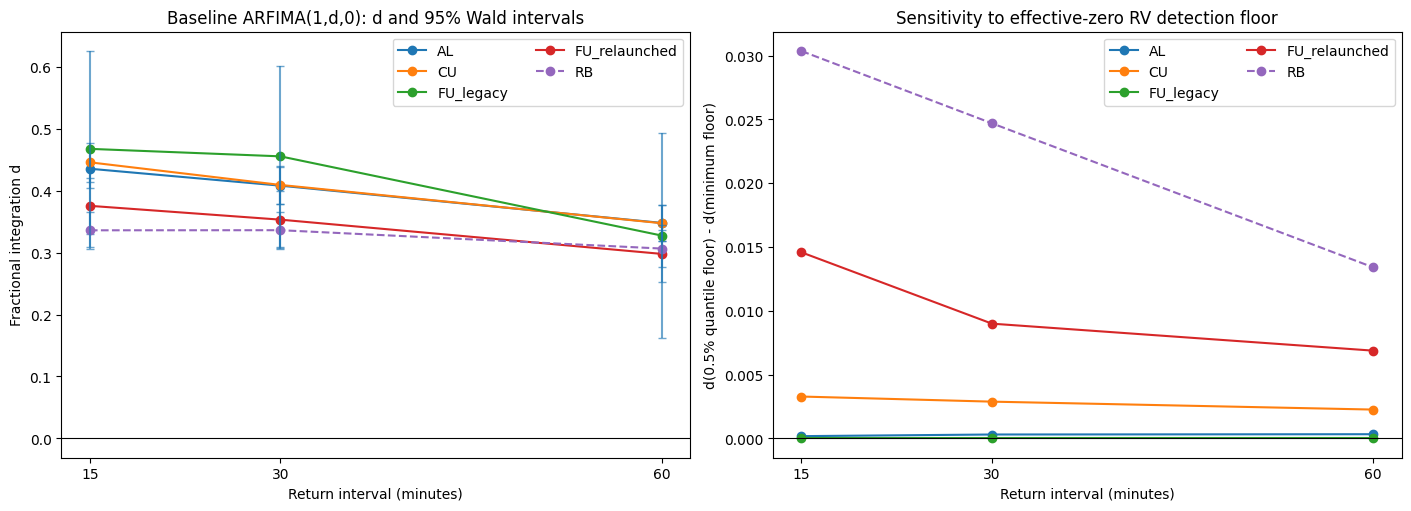

,baseline_models,valid_d_t_values,d_significant_5pct,d_minimum,d_maximum,maximum_zero_treatment_abs_d_change,valid_baseline_covariances
0,15,15,15,0.298002,0.467642,0.030366,15


**当前样本结论。** 15 个基线估计的 `d` 位于 `0.2980`—`0.4676`，其中 `15/15` 在 5% 水平显著；`5/5` 个序列的 60 分钟 `d` 低于 15 分钟 `d`。检测下限敏感性下 `d` 的最大绝对变化为 `0.0304`。RB 的 `(1,d,1)` 相对基线 BIC 低 `36.27`—`49.78`，但 `3/3` 个 `d` 都触及上界，因此只作为边界敏感性，不能据此宣称它在样本外预测中更优。

In [13]:
baseline_d_df = fit_summary_df.loc[
    fit_summary_df["model_variant"] == "baseline",
    ["series_id", "interval_label", "d"],
].rename(columns={"d": "baseline_floor_d"})
quantile_floor_d_df = fit_summary_df.loc[
    fit_summary_df["model_variant"] == "quantile_floor_sensitivity",
    [
        "series_id",
        "interval_label",
        "d",
        "alternative_floor_days",
    ],
].rename(columns={"d": "quantile_floor_d"})
zero_floor_sensitivity_df = baseline_d_df.merge(
    quantile_floor_d_df,
    on=["series_id", "interval_label"],
    validate="one_to_one",
)
zero_floor_sensitivity_df["quantile_minus_minimum_floor_d"] = (
    zero_floor_sensitivity_df["quantile_floor_d"]
    - zero_floor_sensitivity_df["baseline_floor_d"]
)

rb_baseline_df = fit_summary_df.loc[
    (fit_summary_df["series_id"] == "RB")
    & (fit_summary_df["model_variant"] == "baseline")
].copy()
rb_ma_sensitivity_df = fit_summary_df.loc[
    fit_summary_df["model_variant"] == "rb_ma_sensitivity"
].copy()
rb_bic_sensitivity_df = rb_baseline_df[
    ["interval_label", "bic", "ar1", "d"]
].rename(
    columns={
        "bic": "bic_1_d_0",
        "ar1": "ar1_1_d_0",
        "d": "d_1_d_0",
    }
).merge(
    rb_ma_sensitivity_df[
        ["interval_label", "bic", "ar1", "ma1", "d", "boundary_flag"]
    ].rename(
        columns={
            "bic": "bic_1_d_1",
            "ar1": "ar1_1_d_1",
            "ma1": "ma1_1_d_1",
            "d": "d_1_d_1",
            "boundary_flag": "q1_boundary_flag",
        }
    ),
    on="interval_label",
    validate="one_to_one",
)
rb_bic_sensitivity_df["delta_bic_q1_minus_q0"] = (
    rb_bic_sensitivity_df["bic_1_d_1"]
    - rb_bic_sensitivity_df["bic_1_d_0"]
)
rb_bic_sensitivity_df["bic_preferred_order"] = np.where(
    rb_bic_sensitivity_df["delta_bic_q1_minus_q0"] < 0,
    "(1,d,1)",
    "(1,d,0)",
)

display(Markdown("### 有效零 RV 检测下限敏感性"))
display(zero_floor_sensitivity_df.round(6))
display(Markdown("### RB `(1,d,1)` BIC 敏感性"))
display(rb_bic_sensitivity_df.round(6))

baseline_d_parameter_df = baseline_parameter_df.loc[
    baseline_parameter_df["parameter"] == "d"
].copy()
baseline_d_parameter_df["interval_number"] = baseline_d_parameter_df[
    "interval_label"
].map({"15-min": 15, "30-min": 30, "60-min": 60})

figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    constrained_layout=True,
)
for series_id in series_order:
    series_d_df = baseline_d_parameter_df.loc[
        baseline_d_parameter_df["series_id"] == series_id
    ].sort_values("interval_number")
    line_style = "--" if series_id == "RB" else "-"
    axes[0].plot(
        series_d_df["interval_number"],
        series_d_df["estimate"],
        marker="o",
        linestyle=line_style,
        label=series_id,
    )
    valid_standard_error_mask = np.isfinite(series_d_df["standard_error"])
    axes[0].errorbar(
        series_d_df.loc[valid_standard_error_mask, "interval_number"],
        series_d_df.loc[valid_standard_error_mask, "estimate"],
        yerr=1.96
        * series_d_df.loc[valid_standard_error_mask, "standard_error"],
        fmt="none",
        capsize=3,
        alpha=0.65,
    )

axes[0].axhline(0.0, color="black", linewidth=0.8)
axes[0].set_xticks([15, 30, 60])
axes[0].set_xlabel("Return interval (minutes)")
axes[0].set_ylabel("Fractional integration d")
axes[0].set_title("Baseline ARFIMA(1,d,0): d and 95% Wald intervals")
axes[0].legend(ncol=2)

for series_id in series_order:
    series_sensitivity_df = zero_floor_sensitivity_df.loc[
        zero_floor_sensitivity_df["series_id"] == series_id
    ].copy()
    series_sensitivity_df["interval_number"] = series_sensitivity_df[
        "interval_label"
    ].map({"15-min": 15, "30-min": 30, "60-min": 60})
    axes[1].plot(
        series_sensitivity_df["interval_number"],
        series_sensitivity_df["quantile_minus_minimum_floor_d"],
        marker="o",
        linestyle="--" if series_id == "RB" else "-",
        label=series_id,
    )
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set_xticks([15, 30, 60])
axes[1].set_xlabel("Return interval (minutes)")
axes[1].set_ylabel("d(0.5% quantile floor) - d(minimum floor)")
axes[1].set_title("Sensitivity to effective-zero RV detection floor")
axes[1].legend(ncol=2)
plt.show()

significant_d_count = int(
    baseline_d_parameter_df["p_value"].lt(0.05).sum()
)
valid_baseline_covariance_count = int(
    fit_summary_df.loc[
        fit_summary_df["model_variant"] == "baseline",
        "covariance_status",
    ].eq("valid").sum()
)
display(
    pd.DataFrame(
        [
            {
                "baseline_models": len(baseline_d_parameter_df),
                "valid_d_t_values": int(
                    baseline_d_parameter_df["t_value"].notna().sum()
                ),
                "d_significant_5pct": significant_d_count,
                "d_minimum": baseline_d_parameter_df["estimate"].min(),
                "d_maximum": baseline_d_parameter_df["estimate"].max(),
                "maximum_zero_treatment_abs_d_change": (
                    zero_floor_sensitivity_df[
                        "quantile_minus_minimum_floor_d"
                    ].abs().max()
                ),
                "valid_baseline_covariances": valid_baseline_covariance_count,
            }
        ]
    ).round(6)
)

d_frequency_pivot_df = baseline_d_df.pivot(
    index="series_id",
    columns="interval_label",
    values="baseline_floor_d",
)
frequency_decline_count = int(
    (d_frequency_pivot_df["60-min"] < d_frequency_pivot_df["15-min"]).sum()
)
rb_q1_bic_improvement = -rb_bic_sensitivity_df["delta_bic_q1_minus_q0"]
rb_q1_boundary_count = int(
    rb_bic_sensitivity_df["q1_boundary_flag"].astype(bool).sum()
)
display(
    Markdown(
        "**当前样本结论。** "
        f"15 个基线估计的 `d` 位于 "
        f"`{baseline_d_parameter_df['estimate'].min():.4f}`—"
        f"`{baseline_d_parameter_df['estimate'].max():.4f}`，"
        f"其中 `{significant_d_count}/15` 在 5% 水平显著；"
        f"`{frequency_decline_count}/5` 个序列的 60 分钟 `d` 低于 15 分钟 `d`。"
        f"检测下限敏感性下 `d` 的最大绝对变化为 "
        f"`{zero_floor_sensitivity_df['quantile_minus_minimum_floor_d'].abs().max():.4f}`。"
        f"RB 的 `(1,d,1)` 相对基线 BIC 低 "
        f"`{rb_q1_bic_improvement.min():.2f}`—`{rb_q1_bic_improvement.max():.2f}`，"
        f"但 `{rb_q1_boundary_count}/3` 个 `d` 都触及上界，因此只作为边界敏感性，"
        "不能据此宣称它在样本外预测中更优。"
    )
)

## 12. 独立公式复核与验证门禁

In [14]:
representative_key = ("AL", "15-min", "baseline")
representative_context = fit_context_by_key[representative_key]
representative_values = representative_context["log_volatility_values"]
representative_fit_bundle = representative_context["fit_bundle"]
representative_parameters = representative_fit_bundle[
    "optimization_result"
].x
representative_ar1 = representative_parameters[0]
representative_d = representative_parameters[1]

representative_lags = np.arange(
    1, len(representative_values), dtype="float64"
)
manual_fractional_weights = np.r_[
    1.0,
    np.cumprod(
        (representative_lags - 1.0 - representative_d)
        / representative_lags
    ),
]
manual_fractional_values = np.convolve(
    representative_values,
    manual_fractional_weights,
    mode="full",
)[: len(representative_values)]
manual_fractional_constant = np.convolve(
    np.ones(len(representative_values)),
    manual_fractional_weights,
    mode="full",
)[: len(representative_values)]
manual_ar_values = manual_fractional_values.copy()
manual_ar_constant = manual_fractional_constant.copy()
manual_ar_values[1:] -= representative_ar1 * manual_fractional_values[:-1]
manual_ar_constant[1:] -= representative_ar1 * manual_fractional_constant[:-1]
manual_value_component = manual_ar_values[1:]
manual_constant_component = manual_ar_constant[1:]
manual_mean = float(
    np.dot(manual_constant_component, manual_value_component)
    / np.dot(manual_constant_component, manual_constant_component)
)
manual_innovations = (
    manual_value_component - manual_mean * manual_constant_component
)
manual_variance = float(np.mean(np.square(manual_innovations)))
manual_negative_loglikelihood = 0.5 * len(manual_innovations) * (
    np.log(2.0 * np.pi) + 1.0 + np.log(manual_variance)
)
representative_css_error = abs(
    manual_negative_loglikelihood
    - representative_fit_bundle["evaluation"]["negative_loglikelihood"]
)

manual_rv_source_df = multiscale_return_df.loc[
    (multiscale_return_df["series_id"] == "AL")
    & (multiscale_return_df["interval_label"] == "15-min")
].sort_values(["trading_date", "interval_slot"])
manual_first_date = manual_rv_source_df["trading_date"].iloc[0]
manual_first_day_df = manual_rv_source_df.loc[
    manual_rv_source_df["trading_date"] == manual_first_date
]
manual_realized_variance = float(
    np.square(manual_first_day_df["interval_return"]).sum()
)
stored_realized_variance = float(
    daily_realized_variance_df.loc[
        (daily_realized_variance_df["series_id"] == "AL")
        & (daily_realized_variance_df["interval_label"] == "15-min")
        & (daily_realized_variance_df["trading_date"] == manual_first_date),
        "realized_variance",
    ].iloc[0]
)
manual_rv_error = abs(manual_realized_variance - stored_realized_variance)

restoration_maximum_error = float(
    np.max(
        np.abs(
            np.exp(2.0 * daily_realized_variance_df["log_volatility"])
            - daily_realized_variance_df["rv_for_log"]
        )
    )
)

slot_failure_columns = [
    "slot_count_failures",
    "aggregated_minute_count_failures",
    "non_last_slot_length_failures",
    "last_slot_length_failures",
]
sample_endpoint_audit_df = (
    daily_realized_variance_df.groupby("series_id", observed=True)
    .agg(
        first_date=("trading_date", "min"),
        last_date=("trading_date", "max"),
    )
    .reset_index()
    .merge(
        sample_spec_df[
            ["series_id", "sample_start", "sample_end", "research_role"]
        ],
        on="series_id",
        validate="one_to_one",
    )
)
sample_endpoint_audit_df["start_matches"] = (
    sample_endpoint_audit_df["first_date"]
    == sample_endpoint_audit_df["sample_start"]
)
sample_endpoint_audit_df["end_matches"] = (
    sample_endpoint_audit_df["last_date"]
    == sample_endpoint_audit_df["sample_end"]
)

baseline_fit_df = fit_summary_df.loc[
    fit_summary_df["model_variant"] == "baseline"
]
baseline_parameter_constraint_pass = (
    baseline_fit_df["ar1"].abs().le(ar_ma_absolute_bound + 1e-8).all()
    and baseline_fit_df["d"].abs().le(fractional_d_bound + 1e-8).all()
)
all_fit_constraint_pass = (
    fit_summary_df["ar1"].abs().le(ar_ma_absolute_bound + 1e-8).all()
    and fit_summary_df["ma1"].dropna().abs().le(
        ar_ma_absolute_bound + 1e-8
    ).all()
    and fit_summary_df["d"].abs().le(fractional_d_bound + 1e-8).all()
)

fu_legacy_full_end = daily_realized_variance_df.loc[
    daily_realized_variance_df["series_id"] == "FU_legacy",
    "trading_date",
].max()
fu_relaunched_full_start = daily_realized_variance_df.loc[
    daily_realized_variance_df["series_id"] == "FU_relaunched",
    "trading_date",
].min()

validation_gate_df = pd.DataFrame(
    [
        (
            "latitude_environment",
            current_python == expected_python,
            str(current_python),
        ),
        (
            "source_schema_physical_compatibility",
            source_contract_audit_df["physical_mismatch_count"].eq(0).all(),
            ", ".join(source_contract_audit_df["table_name"]),
        ),
        (
            "fixed_sample_endpoints",
            sample_endpoint_audit_df[["start_matches", "end_matches"]]
            .all()
            .all(),
            "; ".join(
                f"{row.series_id}:{row.first_date.date()}..{row.last_date.date()}"
                for row in sample_endpoint_audit_df.itertuples(index=False)
            ),
        ),
        (
            "unique_trade_month_plus_three_contract",
            contract_mapping_audit_df["target_contract_count"].isin([0, 1]).all()
            and contract_series_df["contract_code"].eq(
                contract_series_df["expected_contract_code"]
            ).all()
            and actual_missing_keys_df.equals(known_missing_keys_df),
            "唯一固定三个月合约；仅排除 22 日 FU1102.XSGE 未上市缺口",
        ),
        (
            "day_sessions_and_minute_alignment",
            not contract_calendar_df["is_night_session"].any()
            and not bar_calendar_df["is_night_session"].any()
            and complete_contract_day_df["is_complete_contract_day"].all()
            and minute_read_audit_df["session_alignment_failures"].eq(0).all(),
            f"{len(complete_contract_day_df):,} 合约日；{int(minute_read_audit_df['selected_day_minute_rows'].sum()):,} 日盘分钟",
        ),
        (
            "intraday_slot_structure",
            slot_audit_df[slot_failure_columns].eq(0).all().all(),
            "每日 15/8/4 槽；30/60 分钟末槽严格为 15/45 分钟",
        ),
        (
            "realized_variance_panel_structure",
            len(daily_realized_variance_df) == 14153 * 3
            and daily_realized_variance_df["observed_slots"].eq(
                daily_realized_variance_df["interval_label"].map(
                    {"15-min": 15, "30-min": 8, "60-min": 4}
                )
            ).all()
            and daily_realized_variance_df["total_interval_minutes"].eq(225).all(),
            f"{len(daily_realized_variance_df):,} 个序列日频率 RV；每个严格覆盖 225 分钟",
        ),
        (
            "realized_variance_finite_nonnegative",
            np.isfinite(daily_realized_variance_df["realized_variance"]).all()
            and daily_realized_variance_df["realized_variance"].ge(0).all(),
            f"最小 RV={daily_realized_variance_df['realized_variance'].min():.3e}",
        ),
        (
            "effective_zero_accounting",
            int(daily_realized_variance_df["is_effective_zero_day"].sum()) == 211
            and int(daily_realized_variance_df["is_machine_pseudo_positive_zero"].sum()) == 4
            and int(
                daily_realized_variance_df.loc[
                    daily_realized_variance_df["is_initial_sample"],
                    "is_effective_zero_day",
                ].sum()
            )
            == 133,
            "全文 211、初始 133 个有效零 RV；其中 4 个机器伪正值被识别",
        ),
        (
            "initial_only_rv_detection_floor",
            rv_floor_df["rv_detection_floor"].gt(0).all()
            and rv_floor_df["rv_quantile_detection_floor"]
            .ge(rv_floor_df["rv_detection_floor"])
            .all()
            and np.allclose(
                initial_zero_audit_df["rv_detection_floor"],
                rv_floor_multiplier
                * initial_zero_audit_df["minimum_substantive_positive_rv"],
                rtol=1e-12,
                atol=0.0,
            )
            and np.allclose(
                initial_zero_audit_df["rv_quantile_detection_floor"],
                rv_floor_multiplier
                * initial_zero_audit_df[
                    "substantive_positive_rv_quantile_005"
                ],
                rtol=1e-12,
                atol=0.0,
            )
            and daily_realized_variance_df.loc[
                daily_realized_variance_df["is_effective_zero_day"],
                "rv_for_log",
            ].eq(
                daily_realized_variance_df.loc[
                    daily_realized_variance_df["is_effective_zero_day"],
                    "rv_detection_floor",
                ]
            ).all(),
            "最小值与 0.5% 分位数检测下限均只由初始实质正 RV 决定，并且只替换有效零日",
        ),
        (
            "log_volatility_target_and_restoration",
            np.isfinite(daily_realized_variance_df["log_volatility"]).all()
            and restoration_maximum_error < 1e-16,
            f"0.5*log(RV) 经 exp(2y) 还原最大误差={restoration_maximum_error:.3e}",
        ),
        (
            "initial_and_oos_day_counts",
            model_sample_df.set_index("series_id")["oos_days"].to_dict()
            == {
                "AL": 300,
                "CU": 300,
                "FU_legacy": 200,
                "FU_relaunched": 200,
                "RB": 300,
            }
            and model_sample_df.set_index("series_id")[
                "initial_sample_days"
            ].to_dict()
            == {
                "AL": 3745,
                "CU": 3745,
                "FU_legacy": 204,
                "FU_relaunched": 1414,
                "RB": 3745,
            },
            "; ".join(
                f"{row.series_id}: initial={row.initial_sample_days}, OOS={row.oos_days}"
                for row in model_sample_df.itertuples(index=False)
            ),
        ),
        (
            "fractional_weight_formula",
            fractional_weight_formula_error < 1e-15,
            f"前四项显式二项式误差={fractional_weight_formula_error:.3e}",
        ),
        (
            "manual_rv_and_css_likelihood",
            manual_rv_error
            <= 8.0
            * np.finfo(float).eps
            * max(abs(stored_realized_variance), 1e-4)
            and representative_css_error < 1e-8,
            f"RV 手算误差={manual_rv_error:.3e}; AL 15-min CSS NLL 误差={representative_css_error:.3e}",
        ),
        (
            "complete_model_grid",
            len(fit_summary_df) == 33
            and fit_summary_df["success"].all()
            and len(baseline_fit_df) == 15
            and fit_summary_df["model_variant"]
            .eq("quantile_floor_sensitivity")
            .sum()
            == 15
            and fit_summary_df["model_variant"]
            .eq("rb_ma_sensitivity")
            .sum()
            == 3,
            "15 个基线 + 15 个检测下限敏感性 + 3 个 RB MA 敏感性全部成功",
        ),
        (
            "baseline_likelihood_observations",
            int(baseline_fit_df["likelihood_observations"].sum()) == 38544
            and (
                baseline_fit_df["likelihood_observations"]
                == baseline_fit_df["input_observations"] - 1
            ).all(),
            "15 个基线共 38,544 个似然观察；首日只提供 AR 滞后",
        ),
        (
            "arfima_parameter_constraints",
            baseline_parameter_constraint_pass and all_fit_constraint_pass,
            "|AR|、|MA|<=0.999 且 |d|<=0.499",
        ),
        (
            "conditional_gaussian_variance_finite_positive",
            fit_summary_df["innovation_variance"].gt(0).all()
            and np.isfinite(
                fit_summary_df[
                    [
                        "innovation_variance",
                        "profiled_mean",
                        "loglikelihood",
                    ]
                ].to_numpy()
            ).all(),
            "33 个 Gaussian CSS 的剖面均值、创新方差与似然均有限",
        ),
        (
            "covariance_diagnostics_explicit",
            fit_summary_df["covariance_status"].notna().all()
            and parameter_result_df["covariance_status"].notna().all(),
            f"有效观察 Hessian {fit_summary_df['covariance_status'].eq('valid').sum()}/33；其余显式标记",
        ),
        (
            "rb_ma_bic_sensitivity_comparable",
            len(rb_bic_sensitivity_df) == 3
            and rb_baseline_df["input_observations"].to_numpy().tolist()
            == rb_ma_sensitivity_df["input_observations"].to_numpy().tolist(),
            "RB `(1,d,0)` 与 `(1,d,1)` 每个频率使用完全相同的检测下限初始样本",
        ),
        (
            "fu_segments_are_independent",
            fu_legacy_full_end < fu_relaunched_full_start
            and set(
                fit_summary_df.loc[
                    fit_summary_df["series_id"].str.startswith("FU"),
                    "series_id",
                ]
            )
            == {"FU_legacy", "FU_relaunched"},
            f"legacy_end={fu_legacy_full_end.date()}, relaunched_start={fu_relaunched_full_start.date()}",
        ),
        (
            "rb_extension_is_separate",
            sample_spec_df.loc[
                sample_spec_df["series_id"] == "RB", "research_role"
            ].eq("论文外扩展品种").all()
            and len(
                fit_summary_df.loc[fit_summary_df["series_id"] == "RB"]
            )
            == 9,
            "RB 三频率基线、零日和 MA 敏感性共 9 个拟合独立列示",
        ),
    ],
    columns=["gate", "passed", "evidence"],
)

display(sample_endpoint_audit_df)
display(validation_gate_df)
assert validation_gate_df["passed"].all(), validation_gate_df.loc[
    ~validation_gate_df["passed"]
]

,series_id,first_date,last_date,sample_start,sample_end,research_role,start_matches,end_matches
0,AL,2010-01-04,2026-08-28,2010-01-04,2026-08-28,论文品种,True,True
1,CU,2010-01-04,2026-08-28,2010-01-04,2026-08-28,论文品种,True,True
2,FU_legacy,2010-01-04,2011-09-30,2010-01-04,2011-09-30,论文品种：旧产品段,True,True
3,FU_relaunched,2020-01-02,2026-08-28,2020-01-02,2026-08-28,论文品种：稳定重启段,True,True
4,RB,2010-01-04,2026-08-28,2010-01-04,2026-08-28,论文外扩展品种,True,True


,gate,passed,evidence
0,latitude_environment,True,E:\anaconda3\envs\latitude\python.exe
1,source_schema_physical_compatibility,True,"dim_futures_variety_calendar, dim_futures_contract_calendar, dim_futures_bar_calendar, fact_futures_minute"
2,fixed_sample_endpoints,True,AL:2010-01-04..2026-08-28; CU:2010-01-04..2026-08-28; FU_legacy:2010-01-04..2011-09-30; FU_relaunched:2020-01-02..2026-08-28; RB:2010-01-04..2026-08-28
3,unique_trade_month_plus_three_contract,True,唯一固定三个月合约；仅排除 22 日 FU1102.XSGE 未上市缺口
4,day_sessions_and_minute_alignment,True,"14,153 合约日；3,184,425 日盘分钟"
5,intraday_slot_structure,True,每日 15/8/4 槽；30/60 分钟末槽严格为 15/45 分钟
6,realized_variance_panel_structure,True,"42,459 个序列日频率 RV；每个严格覆盖 225 分钟"
7,realized_variance_finite_nonnegative,True,最小 RV=0.000e+00
8,effective_zero_accounting,True,全文 211、初始 133 个有效零 RV；其中 4 个机器伪正值被识别
9,initial_only_rv_detection_floor,True,最小值与 0.5% 分位数检测下限均只由初始实质正 RV 决定，并且只替换有效零日


## 13. 结果解释与限制

解释顺序：

1. 先看 `d` 的位置、t 值和边界。显著正 `d` 支持实现波动率长记忆；若贴近 `0.499`，只能说平稳域上界附近，不能把普通 Wald t 当作无条件证据。
2. AR(1) 描述分数差分后的短期动态。这里报告常规 `(1-phi*L)` 的递推系数，与 Table 6 和论文正文的负 AR 解释一致；论文公式印刷的 `1+phi*L` 歧义仍须在跨软件比较时检查。
3. 零日敏感性只回答检测下限幅度是否明显改变 `d`；两种口径都保留完整日网格，0.5% 分位数口径不替换最小实质正值基线。
4. RB `(1,d,1)` 的 BIC 若更低，只说明扩展品种的短期 MA 项可能有用；若 `d` 撞到平稳边界，更应把它视为模型设定敏感性，而非稳定结论。
5. `exp(2*y_hat)` 是未来把 log volatility 预测还原为方差的冻结公式；本项不做论文未披露的对数正态偏差修正。

已知限制：

- Gaussian CSS、有限历史初值、平稳域边界、观察 Hessian和零 RV 检测下限都是论文未披露的项目选择；Notebook 已逐项公开并提供可复核门禁。
- 当前 225 分钟日盘使 30/60 分钟末槽短于目标长度；这会影响不同频率 RV 的水平和估计参数，不能与论文 240 分钟交易日机械对齐。
- FU_legacy 初始样本仅 204 日，虽然其初始段没有有效零 RV 日，估计精度和边界仍需谨慎。
- 本项只证明当前样本内的动态结构。ARFIMA 是否优于 GARCH/FIGARCH 必须使用共同 OOS 方差预测、RMSFE、DM–West 与 SPA 才能判断。